# 🚀 **Lab 06: Multimodal Learning with Flickr8k, A Mini CLIP Journey**

### **Instructor: Dr. Andrea Ramirez Salgado**

## Welcome, Multimodal Explorer!

This lab is inspired by the central idea behind CLIP:

> Learn an image encoder and a text encoder so that matching image caption pairs have **similar embeddings**, while mismatched pairs are pushed apart.

You will not reproduce CLIP at industrial scale. Instead, you will build a rigorous **Mini CLIP** system from scratch using **Flickr8k**, a dataset of images paired with multiple human written captions.

---

### 🎯 **What You'll Discover**

1. inspect and prepare a real multimodal dataset  
2. build a caption tokenizer and vocabulary  
3. implement a text encoder with self attention  
4. implement an image encoder with convolutional layers  
5. project both modalities into a shared embedding space  
6. train with a contrastive objective  
7. evaluate retrieval in both directions  
8. analyze what multimodal learning captures, and where it fails

### 🧪 **Your Lab Philosophy**
1. **Experiment First**: Try things, make predictions, then see what happens
2. **Visualize Everything**: Attention weights, embeddings, training curves — see it all
3. **Connect Concepts**: Understand the *why* behind every design decision

### 📊 **Your Progress Tracker**
Throughout this lab, you'll complete:
- 🔵 **Discovery Tasks** — Explore and build intuition
- 🟢 **Implementation Tasks** — Build real NLP components
- 🟡 **Reflection Tasks** — Deepen your understanding
- 🔴 **Challenge Tasks** — Push your limits

---
Let's begin! 🎓

---
# 🛠️ **Setup: Your Multimodal Toolkit**

We will use:

1. **PyTorch** for the models  
2. **torchvision** for image transforms  
3. **kagglehub** to download Flickr8k  
4. **matplotlib** for visualizations  
5. **scikit learn** for embedding visualization

> Important: Flickr8k is larger and richer than the small toy datasets often used in introductory labs. To keep this notebook feasible on CPU, we will optionally work with a **subset** during development.

In [3]:

# Install dependencies if needed
!pip install kagglehub pillow scikit-learn --quiet


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:

import os
import re
import math
import random
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision
import torchvision.transforms as T

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


---
# **Part 1: Understanding the Multimodal Dataset** 🖼️📝

## **Why This Matters**

In a standard classification dataset, each input maps to a class label.  
In a multimodal dataset like Flickr8k, each **image** can map to **multiple captions**, and each caption may highlight a different aspect of the scene.

That means the learning problem is richer:

1. meaning is distributed across two modalities  
2. multiple captions for one image introduce ambiguity  
3. alignment is semantic, not merely categorical

## **1.1 Download and Locate Flickr8k**

### 🔵 **Discovery Task 1: Inspect the Raw Dataset**

**Your Mission**: Download the dataset, inspect the folder structure, and identify:

1. where the images are stored  
2. where the caption file is stored  
3. how image names are matched to captions

Do not move on until you can clearly explain the structure of the data.

In [5]:

import kagglehub

# This download may take some time the first time you run it.
# If you already have a local copy, point DATA_ROOT to that directory instead.

DATA_ROOT = Path(kagglehub.dataset_download("aladdinpersson/flickr8kimagescaptions"))
print("Downloaded dataset root:", DATA_ROOT)

# Explore the directory tree at a shallow depth
for path in sorted(DATA_ROOT.rglob("*")):
    rel = path.relative_to(DATA_ROOT)
    depth = len(rel.parts)
    if depth <= 2:
        print(rel)

Downloaded dataset root: C:\Users\HP\.cache\kagglehub\datasets\aladdinpersson\flickr8kimagescaptions\versions\1
flickr8k
flickr8k\captions.txt
flickr8k\images


In [6]:

# Helper: try to automatically find the image directory and the caption text file

image_dir = None
caption_file = None

for p in DATA_ROOT.rglob("*"):
    if p.is_dir() and "image" in p.name.lower():
        image_dir = p if image_dir is None else image_dir
    if p.is_file() and p.suffix.lower() == ".txt" or "token" in p.name.lower():
        caption_file = p if caption_file is None else caption_file

print("Candidate image directory:", image_dir)
print("Candidate caption file:", caption_file)

Candidate image directory: C:\Users\HP\.cache\kagglehub\datasets\aladdinpersson\flickr8kimagescaptions\versions\1\flickr8k\images
Candidate caption file: C:\Users\HP\.cache\kagglehub\datasets\aladdinpersson\flickr8kimagescaptions\versions\1\flickr8k\captions.txt


### 🟡 **Reflection 1: Dataset Structure**

1. How is multimodal supervision represented here?  
The model learns by looking at images and their matching captions together. It has two "readers" one for images and one for text. The training teaches it one simple rule: if an image and a caption match, bring them close together, and if they don't match, push them far apart. Think of it like teaching a dog to recognize its owner's voice. Over time, the dog learns what belongs together and what doesn't. To make this work, there's an image reader, a text reader, and two small "translator" layers that convert both into the same format so they can be directly compared. There's also a temperature setting that keeps the whole training process stable and smooth.

2. Why might **five captions per image** be more useful than only one? 
Having five different captions for the same image is like getting five people to describe a photo each one notices something different. This gives the model much more to learn from. It sees more details, more ways of saying the same thing, and more examples of what actually "matches" an image. Because of this variety, the model doesn't get stuck memorizing one specific sentence. Instead it learns the deeper concept behind the image, which makes it smarter and more flexible when it sees new captions later.

3. What challenges do you anticipate when the captions for the same image are not identical in wording or emphasis?
When five people write captions for the same photo, they won't all say the same thing, and that creates some real challenges. The model has to figure out which differences actually matter and which are just casual variations in wording. Some caption differences are random or unimportant, which can confuse the model and muddy the learning signal. On top of that, you can't force all five captions to produce perfectly identical results in the model's mind, nor should you, the goal is just to get them "close enough" while still keeping useful detail. Using all five captions at once also takes more computing power and requires thoughtful design decisions. The training formula itself needs to be strong enough to handle all this variation without falling apart. In short, more captions means richer learning, but it also demands more careful engineering along the way.


## **1.2 Parse the Captions**

### 🟢 **Implementation Task 1: Build the Caption Table**

**Your Mission**: Complete the parser below so that it builds:

1. `image_to_captions`, a dictionary mapping each image filename to a list of captions  
2. `pairs`, a flat list of `(image_filename, caption)` examples

This is the first point where you must handle a real world text file format carefully.

In [7]:
def parse_flickr8k_captions(caption_path: str):
    '''
    Parse the Flickr8k token file.

    Expected output:
        image_to_captions: dict[str, list[str]]
        pairs: list[tuple[str, str]]

    Hint:
        Typical lines look like:
            1000268201_693b08cb0e.jpg#0\tA child in a pink dress is climbing up a set of stairs .

    Requirements:
        1. Ignore empty lines.
        2. Split each valid line into image identifier and caption text.
        3. Remove the trailing caption index after the # symbol.
        4. Store all captions for each image in a list.
        5. Also build a flat list of (image_name, caption) pairs.
    '''
    image_to_captions = defaultdict(list)
    pairs = []

    with open(caption_path, "r", encoding="utf-8") as f:
        lines = f.readlines()

    for line in lines:
        line = line.strip()
        if not line:
            continue
        if line.startswith("image,caption"):
            continue
        parts = line.split(",", 1)
        if len(parts) != 2:
            continue
        image_name, caption = parts
        image_to_captions[image_name].append(caption)
        pairs.append((image_name, caption))

    return dict(image_to_captions), pairs

# Run this only after you implement the parser.
image_to_captions, pairs = parse_flickr8k_captions(caption_file)

print("Number of unique images:", len(image_to_captions))
print("Number of image-caption pairs:", len(pairs))

# Basic sanity checks
assert isinstance(image_to_captions, dict)
assert isinstance(pairs, list)
assert len(image_to_captions) > 0, "Your parser returned no images."
assert len(pairs) > 0, "Your parser returned no pairs."


Number of unique images: 8091
Number of image-caption pairs: 40455


In [8]:

# Inspect a few examples
sample_images = list(image_to_captions.keys())[:3]
for img_name in sample_images:
    print("=" * 90)
    print("IMAGE:", img_name)
    for i, cap in enumerate(image_to_captions[img_name]):
        print(f"Caption {i+1}: {cap}")

IMAGE: 1000268201_693b08cb0e.jpg
Caption 1: A child in a pink dress is climbing up a set of stairs in an entry way .
Caption 2: A girl going into a wooden building .
Caption 3: A little girl climbing into a wooden playhouse .
Caption 4: A little girl climbing the stairs to her playhouse .
Caption 5: A little girl in a pink dress going into a wooden cabin .
IMAGE: 1001773457_577c3a7d70.jpg
Caption 1: A black dog and a spotted dog are fighting
Caption 2: A black dog and a tri-colored dog playing with each other on the road .
Caption 3: A black dog and a white dog with brown spots are staring at each other in the street .
Caption 4: Two dogs of different breeds looking at each other on the road .
Caption 5: Two dogs on pavement moving toward each other .
IMAGE: 1002674143_1b742ab4b8.jpg
Caption 1: A little girl covered in paint sits in front of a painted rainbow with her hands in a bowl .
Caption 2: A little girl is sitting in front of a large painted rainbow .
Caption 3: A small girl in 

### 🔵 **Discovery Task 2: Caption Diversity**

Pick one image and read all five captions.

1. What information is repeated across the captions?  
2. What information changes?  
3. Which words are precise, and which are more subjective or interpretive?

This is your first hint that multimodal learning is not just class prediction with two inputs.

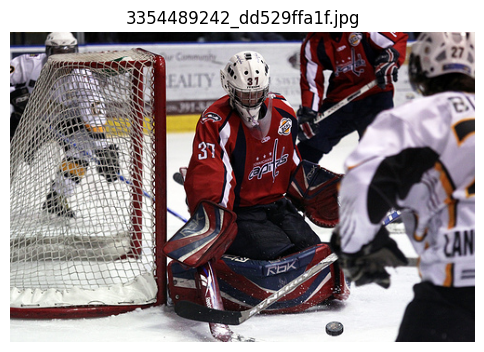

1. A goalie tries to block the puck in a hockey game .
2. A hockey goalie stops the puck .
3. People playing hockey .
4. Several hockey players move toward the puck next to a goal .
5. Two hockey teams compete .


In [9]:

# Visualize one image with all of its captions

def show_image_with_captions(img_name, image_dir, image_to_captions):
    img_path = Path(image_dir) / img_name
    img = Image.open(img_path).convert("RGB")
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.title(img_name)
    plt.show()

    for i, cap in enumerate(image_to_captions[img_name]):
        print(f"{i+1}. {cap}")

example_name = random.choice(list(image_to_captions.keys()))
show_image_with_captions(example_name, image_dir, image_to_captions)

### 🟡 **Reflection 2: Why Contrastive Learning?**

Suppose you trained a classifier to predict a single caption ID for each image.

1. Why would that be a poor formulation of this task?  
Because there is no real relationship between caption IDs and meaning. Caption ID 1 and Caption ID 2 are just arbitrary numbers, the model would be memorizing labels rather than understanding anything. On top of that, the same image has five valid captions, so forcing the model to pick one "correct" ID and treat the other four as wrong is simply a false problem. It would never generalize to captions it hasn't seen before.

2. Why is it more sensible to learn a shared embedding space instead?  
Because it teaches the model to understand meaning rather than memorize labels. In a shared space, the model learns that an image of a dog and the sentence "a dog running in the park" belong near each other, not because of an ID match, but because they genuinely describe the same thing. This also means the model can handle brand new captions it has never seen, as long as they are semantically close to what it learned.

3. In your own words, what should it mean for an image and caption to be **close** in that space?
It should mean they are talking about the same thing. If you show the model a photo of a hockey game and the caption "a goalie blocks the puck," those two should land near each other in the embedding space because one is the visual version of what the other is saying in words. Closeness in that space is essentially the model's way of saying "yes, these belong together."



---
# **Part 2: From Captions to Tensors** 🧠

## **Why This Matters**

Before a model can align captions with images, it must convert language into vectors.  
As in the previous lab, this involves:

1. tokenization  
2. vocabulary construction  
3. encoding sequences to fixed length tensors  
4. handling unknown words and padding

## **2.1 Tokenization and Vocabulary**

### 🔵 **Discovery Task 3: Compare Tokenization Decisions**

Caption language is shorter than movie reviews, but it still contains punctuation, numbers, plural forms, and descriptive variation.

Study the tokenizer below and think carefully:

1. What information does it preserve?  
2. What information does it throw away?  
3. What kinds of captions might become harder to distinguish because of this choice?

In [10]:

def tokenize(text: str):
    '''
    A simple caption tokenizer:
        lowercase
        keep only letters and numbers
        split on whitespace
    '''
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", "", text)
    return text.split()

sample_caption = "A brown dog jumps over a log, while another dog watches nearby."
print("Original:", sample_caption)
print("Tokens:", tokenize(sample_caption))

Original: A brown dog jumps over a log, while another dog watches nearby.
Tokens: ['a', 'brown', 'dog', 'jumps', 'over', 'a', 'log', 'while', 'another', 'dog', 'watches', 'nearby']


### 🟢 **Implementation Task 2: Build the Vocabulary**

**Your Mission**: Build a vocabulary from the training captions only.

Required special tokens:

1. `<PAD>`  
2. `<UNK>`  
3. `<SOS>`  
4. `<EOS>`

You should also introduce a minimum frequency threshold so that very rare words map to `<UNK>`.

In [11]:

# Optional speed setting
MAX_IMAGES = None   # set to None to use the full dataset
MIN_WORD_FREQ = 3
MAX_LEN = 20

all_image_names = sorted(image_to_captions.keys())
if MAX_IMAGES is not None:
    all_image_names = all_image_names[:MAX_IMAGES]

# Build a reduced dictionary and pair list for faster experimentation
reduced_image_to_captions = {img: image_to_captions[img] for img in all_image_names}
reduced_pairs = [(img, cap) for img in all_image_names for cap in image_to_captions[img]]

print("Using images:", len(reduced_image_to_captions))
print("Using pairs:", len(reduced_pairs))

Using images: 8091
Using pairs: 40455


In [12]:
def build_vocab(captions, min_freq=2):
    '''
    Build a vocabulary from a list of caption strings.

    Requirements:
        1. Tokenize each caption.
        2. Count token frequencies.
        3. Create special tokens first in this exact order:
           <PAD>, <UNK>, <SOS>, <EOS>
        4. Add only words whose frequency is at least min_freq.
        5. Return:
            stoi: token -> id
            itos: id -> token
            counter: Counter of raw token frequencies
    '''
    counter = Counter()

    for caption in captions:
        tokens = caption.lower().split()
        counter.update(tokens)

    specials = ["<PAD>", "<UNK>", "<SOS>", "<EOS>"]
    stoi = {tok: idx for idx, tok in enumerate(specials)}
    itos = {idx: tok for tok, idx in stoi.items()}

    for word, freq in counter.items():
        if freq >= min_freq:
            idx = len(stoi)
            stoi[word] = idx
            itos[idx] = word
        
    return stoi, itos, counter

all_reduced_captions = [cap for _, cap in reduced_pairs]
stoi, itos, word_counter = build_vocab(all_reduced_captions, min_freq=MIN_WORD_FREQ)

print("Vocabulary size:", len(stoi))
print("Most common words:", word_counter.most_common(20))

assert "<PAD>" in stoi and stoi["<PAD>"] == 0
assert "<UNK>" in stoi and "<SOS>" in stoi and "<EOS>" in stoi
assert len(stoi) > 10, "Your vocabulary looks too small."


Vocabulary size: 4160
Most common words: [('a', 61752), ('.', 34212), ('in', 18965), ('the', 18249), ('on', 10732), ('is', 9345), ('and', 8851), ('dog', 8126), ('with', 7761), ('man', 7238), ('of', 6712), ('two', 5224), ('white', 3935), ('black', 3825), ('boy', 3561), ('are', 3504), ('woman', 3385), ('girl', 3320), (',', 3210), ('to', 3173)]


### 📊 **Visualization 1: Caption Word Distribution**

A multimodal model is only as good as the textual signals it can represent.  
Inspect the frequency distribution below and think about what the vocabulary emphasizes.

1. Are the most frequent words semantic, grammatical, or both?  
2. What important words might become rare and get mapped to `<UNK>`?  
3. How might that affect retrieval?

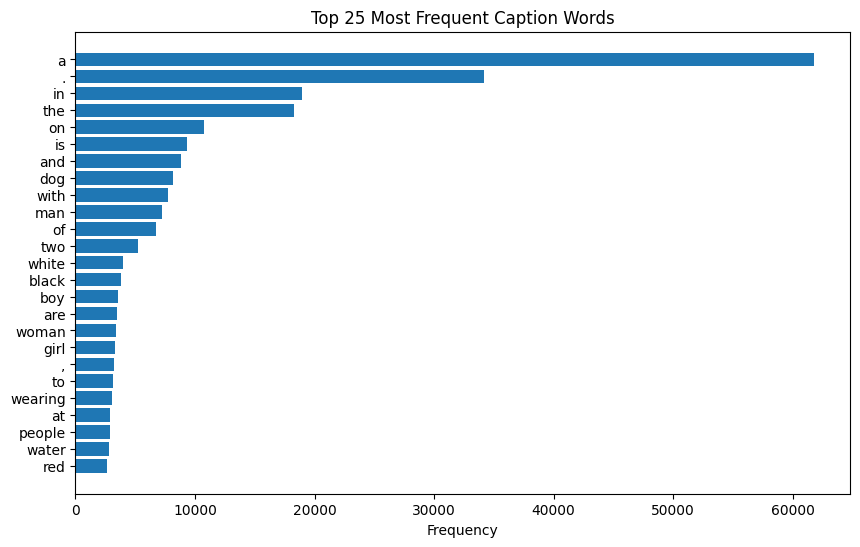

In [13]:

top_words = word_counter.most_common(25)
words, counts = zip(*top_words)

plt.figure(figsize=(10, 6))
plt.barh(words[::-1], counts[::-1])
plt.title("Top 25 Most Frequent Caption Words")
plt.xlabel("Frequency")
plt.show()

### 🟢 **Implementation Task 3: Encode a Caption**

**Your Mission**: Complete the function below.

Your encoder should:

1. tokenize the caption  
2. prepend `<SOS>`  
3. append `<EOS>`  
4. map words to IDs  
5. pad or truncate to `max_len`

Return a tensor of shape `(max_len,)`.

In [14]:
def encode_caption(caption: str, stoi: dict, max_len: int = 20):
    '''
    Convert one caption string into a tensor of token ids.

    Required steps:
        1. tokenize the caption
        2. prepend <SOS>
        3. append <EOS>
        4. map unknown words to <UNK>
        5. pad with <PAD> if needed
        6. truncate to max_len if needed

    Return:
        torch.LongTensor of shape (max_len,)
    '''

    tokens = caption.lower().split()

    ids = [stoi["<SOS>"]] + [stoi.get(tok, stoi["<UNK>"]) for tok in tokens] + [stoi["<EOS>"]]

    if len(ids) < max_len:
        ids = ids + [stoi["<PAD>"]] * (max_len - len(ids))
    else:
        ids = ids[:max_len]
    return torch.LongTensor(ids)

# Run this after implementation.
test_encoded = encode_caption("A child runs through the grass", stoi, max_len=MAX_LEN)
print(test_encoded)
print([itos.get(i.item(), "?") for i in test_encoded])

assert isinstance(test_encoded, torch.Tensor)
assert test_encoded.shape[0] == MAX_LEN


tensor([  2,   4,   5, 125, 120,  25,  67,   3,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0])
['<SOS>', 'a', 'child', 'runs', 'through', 'the', 'grass', '<EOS>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>']


### 🔵 **Discovery Task 4: Truncation and Meaning**

Try a long caption and inspect what gets lost when `max_len` is small.

1. Which kinds of words are most likely to be truncated, early or late?  
2. If the most informative phrase appears near the end, what problem does that create?  
3. How might attention help, and how might it still be insufficient?

In [15]:

long_caption = "A young boy in a red shirt is running through a grassy park while a black dog jumps beside him and another child watches from the background."
encoded = encode_caption(long_caption, stoi, max_len=12)
decoded = [itos.get(i.item(), "?") for i in encoded]
print(decoded)

['<SOS>', 'a', 'young', 'boy', 'in', 'a', 'red', 'shirt', 'is', 'running', 'through', 'a']


---
# **Part 3: Building the Paired Dataset** 🔗

## **Why This Matters**

CLIP style learning does not operate on isolated images or isolated texts.  
It learns from **paired examples**, and each mini batch becomes a small retrieval problem:

1. each image should match its own caption  
2. each image should not match the other captions in the batch  
3. the batch itself creates positive and negative examples

## **3.1 Train Validation Split by Image**

### 🟡 **Reflection 3: Leakage Warning**

If you split by **caption pair**, the same image could appear in both train and validation through different captions.

1. Why would that be a serious leakage problem? 
Because the model would have already seen the image during training, just paired with a different caption. So when it encounters that same image in validation, it isn't really being tested on anything new, it has essentially memorized the visual features of that image already. The validation score would look great on paper but mean nothing in practice, because the model never actually had to generalize to unseen images.

2. Why must the split happen at the **image level** instead?
Because the whole point of validation is to test the model on things it has never seen before. If you split at the image level, every image in the validation set is completely new to the model, it has never seen that photo in any form during training. This gives you an honest measure of whether the model has truly learned to connect visual and language meaning, or whether it was just memorizing specific image-caption combinations.

In [16]:

all_images = list(reduced_image_to_captions.keys())
random.shuffle(all_images)

split_idx = int(0.8 * len(all_images))
train_images = all_images[:split_idx]
val_images = all_images[split_idx:]

train_pairs = [(img, cap) for img in train_images for cap in reduced_image_to_captions[img]]
val_pairs = [(img, cap) for img in val_images for cap in reduced_image_to_captions[img]]

print("Train images:", len(train_images))
print("Validation images:", len(val_images))
print("Train pairs:", len(train_pairs))
print("Validation pairs:", len(val_pairs))

Train images: 6472
Validation images: 1619
Train pairs: 32360
Validation pairs: 8095


## **3.2 PyTorch Dataset for Multimodal Learning**

### 🟢 **Implementation Task 4: Build the Flickr8k Pair Dataset**

Each dataset example should return:

1. transformed image tensor  
2. encoded caption tensor  
3. raw caption text  
4. image filename

This will make later analysis much easier.

In [17]:
image_transform = T.Compose([
    T.Resize((128, 128)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
])

class Flickr8kPairDataset(Dataset):
    def __init__(self, pairs, image_dir, stoi, max_len=20, transform=None):
        self.pairs = pairs
        self.image_dir = Path(image_dir)
        self.stoi = stoi
        self.max_len = max_len
        self.transform = transform

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        '''
        Return a dictionary with:
            image: transformed image tensor
            caption_ids: encoded caption tensor
            caption_text: original caption string
            image_name: image filename
        '''
        image_name, caption = self.pairs[idx]
        image_path = self.image_dir / image_name
        image = Image.open(image_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        caption_ids = encode_caption(caption, self.stoi, self.max_len)
        return {
            "image": image,
            "caption_ids": caption_ids,
            "caption_text": caption,
            "image_name": image_name
        }

train_dataset = Flickr8kPairDataset(train_pairs, image_dir, stoi, max_len=MAX_LEN, transform=image_transform)
val_dataset = Flickr8kPairDataset(val_pairs, image_dir, stoi, max_len=MAX_LEN, transform=image_transform)

# Run these checks after implementation.
sample = train_dataset[0]
print(sample.keys())
print(sample["image"].shape, sample["caption_ids"].shape)
assert "image" in sample and "caption_ids" in sample and "caption_text" in sample and "image_name" in sample


dict_keys(['image', 'caption_ids', 'caption_text', 'image_name'])
torch.Size([3, 128, 128]) torch.Size([20])


In [18]:

BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

batch = next(iter(train_loader))
print("Image batch shape:", batch["image"].shape)
print("Caption batch shape:", batch["caption_ids"].shape)
print("Example caption:", batch["caption_text"][0])
print("Example image name:", batch["image_name"][0])

Image batch shape: torch.Size([64, 3, 128, 128])
Caption batch shape: torch.Size([64, 20])
Example caption: Three men with mouths open and one is holding a fake sword
Example image name: 3016708786_3591106cca.jpg


### 📊 **Visualization 2: Batch Inspection**

Before any learning happens, inspect what one batch actually contains.

1. Are the captions short, long, repetitive, diverse?  
2. Are some images likely to be semantically similar even if they are not exact matches?  
3. Why does that make contrastive learning non trivial?

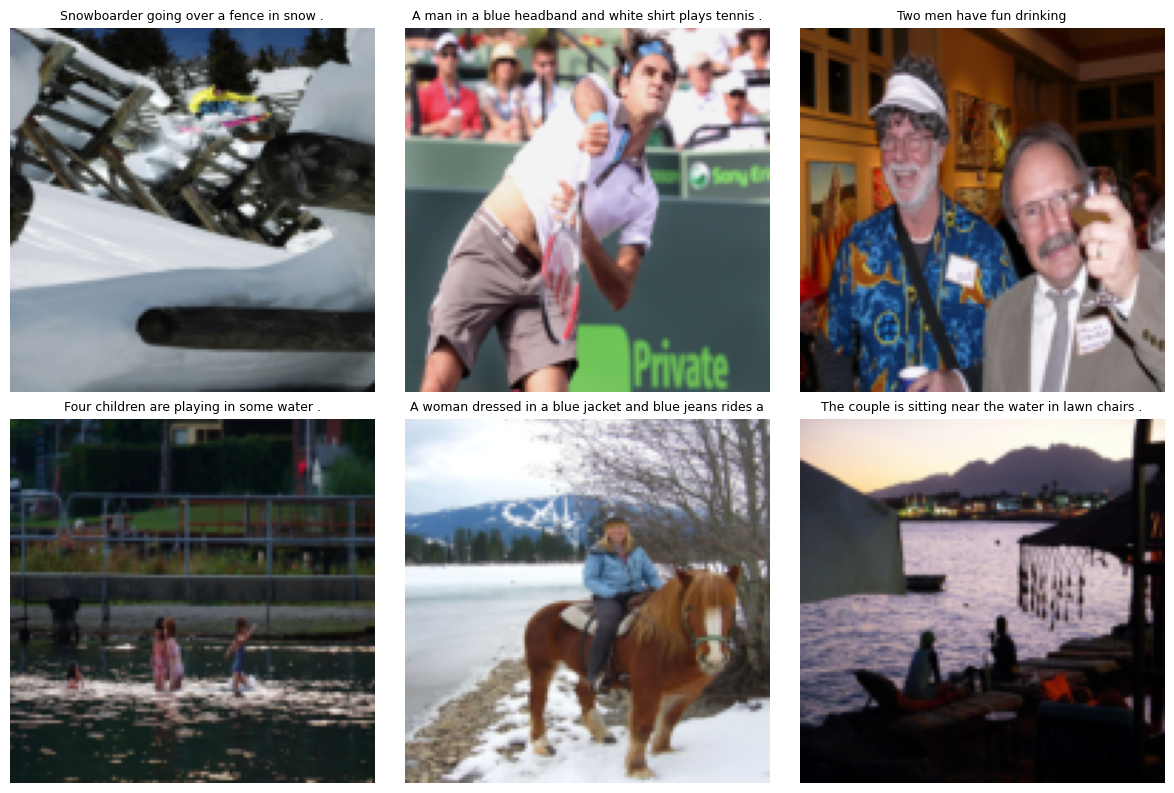

In [19]:

def denormalize(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return (img_tensor.cpu() * std + mean).clamp(0, 1)

sample_batch = next(iter(train_loader))
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for i in range(6):
    axes[i].imshow(denormalize(sample_batch["image"][i]).permute(1, 2, 0))
    axes[i].set_title(sample_batch["caption_text"][i][:55], fontsize=9)
    axes[i].axis("off")

plt.tight_layout()
plt.show()

---
# **Part 4: The Mini CLIP Architecture** 🧩

## **Why This Matters**

A CLIP style model has three conceptual pieces:

1. an **image encoder**  
2. a **text encoder**  
3. a **shared embedding space**

The two encoders do not need to produce identical internal features.  
They only need to produce embeddings that become comparable after projection.

## **4.1 Text Encoder with Self Attention**

### 🔵 **Discovery Task 5: What Should the Text Encoder Output?**

A caption contains multiple token embeddings. But the contrastive loss needs **one vector per caption**.

1. Should we use the final token only?  
2. Mean pooling over all token states?  
3. A learned special token representation?  
4. Which choice is simplest and most stable for this lab, and why?

### 🟢 **Implementation Task 5: Positional Encoding and Text Encoder**

You will implement the caption branch.

Your text encoder should:

1. embed token IDs  
2. add positional encodings  
3. pass the sequence through a Transformer encoder  
4. ignore `<PAD>` positions with a mask  
5. pool the sequence into one caption vector

Keep the design simple, but make your masking and pooling correct.


In [20]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=100):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)  # (1, max_len, d_model)
        self.register_buffer("pe", pe)

    def forward(self, x):
        # x shape: (B, L, D)
        return x + self.pe[:, :x.size(1), :]


In [21]:
class TextEncoder(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, num_heads=4, num_layers=2, ff_dim=256, max_len=20, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=stoi["<PAD>"])
        self.positional = PositionalEncoding(embed_dim, max_len=max_len)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=ff_dim,
            dropout=dropout,
            batch_first=True,
            activation="gelu"
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

    def forward(self, token_ids):
        '''
        token_ids: (B, L)

        Returns:
            pooled caption embedding: (B, D)
            token representations: (B, L, D)
        '''

        # 1. embed tokens
        x = self.embedding(token_ids)

        # 2. add positional encoding
        x = self.positional(x)

        # 3. create padding mask (True where PAD)
        pad_mask = (token_ids == stoi["<PAD>"])

        # 4. run transformer encoder
        hidden = self.encoder(x, src_key_padding_mask=pad_mask)

        # 5. mean-pool over non-PAD positions only
        non_pad = (~pad_mask).unsqueeze(-1).float()
        pooled = (hidden * non_pad).sum(dim=1) / non_pad.sum(dim=1).clamp(min=1)

        # 6. return pooled, hidden
        return pooled, hidden

# Run this sanity check after implementation.
dummy_tokens = torch.randint(0, len(stoi), (4, MAX_LEN))
text_encoder = TextEncoder(vocab_size=len(stoi), max_len=MAX_LEN)
pooled, hidden = text_encoder(dummy_tokens)
print("Pooled shape:", pooled.shape)
print("Hidden shape:", hidden.shape)


Pooled shape: torch.Size([4, 128])
Hidden shape: torch.Size([4, 20, 128])


### 🟢 **Implementation Task 5: Image Encoder**

For the image branch, you will implement a compact CNN backbone.

**Your Mission**:

1. use convolutional layers to extract spatial features  
2. reduce them to one global representation  
3. produce one vector per image

You may later replace this encoder with a pretrained backbone as an extension.

In [22]:
class ImageEncoder(nn.Module):
    def __init__(self, out_dim=256):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.fc = nn.Linear(256, out_dim)

    def forward(self, images):
        x = self.features(images)
        x = x.view(x.size(0), -1)
        return self.fc(x)

# Sanity check
dummy_images = torch.randn(4, 3, 128, 128)
image_encoder = ImageEncoder(out_dim=256)
image_features = image_encoder(dummy_images)
print("Image feature shape:", image_features.shape)


Image feature shape: torch.Size([4, 256])


## **4.2 Shared Embedding Space and Projection Heads**

### 🟡 **Reflection 4: Why Project Both Modalities?**

Even if the image encoder and text encoder both produce vectors, those vectors are not automatically comparable.

1. Why is a learned projection head useful?  
The image encoder and text encoder are completely separate networks trained on different types of input. The vectors they produce live in different spaces with different scales and structures — they can't be directly compared. The projection head is a small learned layer that maps both into a single shared space where comparison actually makes sense. It also gives the model flexibility to adjust the representation without changing the encoders themselves.

2. Why do we often normalize embeddings before computing similarity?  
Without normalization, vectors with larger magnitudes will dominate the similarity calculation regardless of direction. Normalizing forces every vector to have length 1, so the only thing that matters is the angle between them, not how big they are. This makes comparisons fair and consistent across all images and captions in a batch.

3. What geometric meaning does cosine similarity have here?
Cosine similarity measures the angle between two vectors. If two vectors point in exactly the same direction the similarity is 1, if they are perpendicular it is 0, and if they point in opposite directions it is -1. In the shared embedding space this means a matching image and caption should point in nearly the same direction, while unrelated pairs should point in very different directions. The model is essentially learning to align the "direction" of meaning across two completely different modalities.

In [23]:
class MiniCLIP(nn.Module):
    def __init__(self, vocab_size, text_dim=128, image_dim=256, proj_dim=128, max_len=20):
        super().__init__()
        self.text_encoder = TextEncoder(vocab_size, embed_dim=text_dim, max_len=max_len)
        self.image_encoder = ImageEncoder(out_dim=image_dim)

        self.text_proj = nn.Linear(text_dim, proj_dim)
        self.image_proj = nn.Linear(image_dim, proj_dim)

        self.logit_scale = nn.Parameter(torch.tensor(math.log(1 / 0.07)))

    def encode_text(self, token_ids):
        pooled, hidden = self.text_encoder(token_ids)
        projected = self.text_proj(pooled)
        normalized = F.normalize(projected, dim=-1)
        return normalized, hidden

    def encode_image(self, images):
        features = self.image_encoder(images)
        projected = self.image_proj(features)
        normalized = F.normalize(projected, dim=-1)
        return normalized

    def forward(self, images, token_ids):
        image_emb = self.encode_image(images)
        text_emb, text_hidden = self.encode_text(token_ids)

        scale = self.logit_scale.exp()
        logits = scale * image_emb @ text_emb.T

        return logits, image_emb, text_emb, text_hidden

# Run this after implementation.
model = MiniCLIP(vocab_size=len(stoi), max_len=MAX_LEN).to(device)
dummy_images = torch.randn(8, 3, 128, 128).to(device)
dummy_tokens = torch.randint(0, len(stoi), (8, MAX_LEN)).to(device)
logits, image_emb, text_emb, text_hidden = model(dummy_images, dummy_tokens)
print(logits.shape, image_emb.shape, text_emb.shape, text_hidden.shape)


torch.Size([8, 8]) torch.Size([8, 128]) torch.Size([8, 128]) torch.Size([8, 20, 128])


## **4.3 Contrastive Loss by Batch Alignment**

### 🔵 **Discovery Task 6: Read the Similarity Matrix**

In a batch of size `B`, the similarity matrix has shape `(B, B)`.

The diagonal entries represent **correct image caption matches**.  
The off diagonal entries represent mismatches.

Study this carefully before implementing the loss:

1. Why does one batch create many negatives automatically?  
2. Why can some off diagonal pairs still be semantically similar?  
3. Why does that make the task challenging even when the labels are simple?

In [24]:
def clip_loss(logits):
    '''
    Symmetric contrastive loss.

    logits shape: (B, B)

    Requirements:
        1. Construct the correct target indices.
        2. Compute image-to-text cross-entropy.
        3. Compute text-to-image cross-entropy.
        4. Return their average.
    '''
    B = logits.size(0)
    targets = torch.arange(B, device=logits.device)
    
    loss_i2t = F.cross_entropy(logits, targets)
    loss_t2i = F.cross_entropy(logits.T, targets)
    
    return (loss_i2t + loss_t2i) / 2

# Quick shape sanity check after implementation
dummy_logits = torch.randn(8, 8)
print("Dummy loss:", clip_loss(dummy_logits).item())


Dummy loss: 2.348053216934204


### 🟢 **Implementation Task 6: Build a Retrieval Accuracy Function**

**Your Mission**: Implement a simple top 1 retrieval metric.

For a batch:

1. image to text accuracy asks whether each image's highest similarity caption is the matching one  
2. text to image accuracy asks the reverse

This is not a perfect evaluation of the whole dataset, but it is a strong first diagnostic.

In [25]:

def batch_retrieval_accuracy(logits):
    B = logits.size(0)
    targets = torch.arange(B, device=logits.device)

    i2t_acc = (logits.argmax(dim=1) == targets).float().mean().item()
    t2i_acc = (logits.argmax(dim=0) == targets).float().mean().item()

    return i2t_acc, t2i_acc

# Sanity check after implementation
dummy_logits = torch.eye(5)
print(batch_retrieval_accuracy(dummy_logits))


(1.0, 1.0)


---
# **Part 5: Training the Multimodal Model** 🔥

## **Why This Matters**

The training loop looks familiar, but the objective is different from standard classification.

Here, the model is not trying to predict one of a fixed set of labels.  
It is trying to shape the geometry of two embedding spaces so that matching pairs align.

## **5.1 Training Infrastructure**

### 🟢 **Implementation Task 7: Complete the Training and Validation Loop**

Read the code carefully. Notice the outputs you are tracking:

1. contrastive loss  
2. image to text retrieval accuracy  
3. text to image retrieval accuracy

These are more informative than raw loss alone.

In [26]:
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0.0
    total_i2t = 0.0
    total_t2i = 0.0
    steps = 0

    for batch in loader:
        images = batch["image"].to(device)
        token_ids = batch["caption_ids"].to(device)

        optimizer.zero_grad()

        logits, image_emb, text_emb, text_hidden = model(images, token_ids)

        loss = clip_loss(logits)
        loss.backward()
        optimizer.step()

        i2t_acc, t2i_acc = batch_retrieval_accuracy(logits)

        total_loss += loss.item()
        total_i2t += i2t_acc
        total_t2i += t2i_acc
        steps += 1

    return total_loss / steps, total_i2t / steps, total_t2i / steps


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    total_loss = 0.0
    total_i2t = 0.0
    total_t2i = 0.0
    steps = 0

    for batch in loader:
        images = batch["image"].to(device)
        token_ids = batch["caption_ids"].to(device)

        logits, image_emb, text_emb, text_hidden = model(images, token_ids)

        loss = clip_loss(logits)
        i2t_acc, t2i_acc = batch_retrieval_accuracy(logits)

        total_loss += loss.item()
        total_i2t += i2t_acc
        total_t2i += t2i_acc
        steps += 1

    return total_loss / steps, total_i2t / steps, total_t2i / steps


### 🧪 **Experiment 1: Train the Model**

Before training, make a prediction.

1. Will loss decrease quickly or slowly?  
2. Will image to text retrieval and text to image retrieval rise at the same speed? Why or why not?  
3. What failure mode do you expect first: weak caption understanding, weak visual features, or both?

*My prediction:*

After you train, record:

1. final train and validation loss  
2. final train and validation retrieval in both directions  
3. one thing that improved more than expected  
4. one thing that improved less than expected


In [27]:

EPOCHS = 5
LR = 3e-4

model = MiniCLIP(vocab_size=len(stoi), max_len=MAX_LEN).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

history = {
    "train_loss": [],
    "val_loss": [],
    "train_i2t": [],
    "train_t2i": [],
    "val_i2t": [],
    "val_t2i": [],
}

for epoch in range(EPOCHS):
    train_loss, train_i2t, train_t2i = train_one_epoch(model, train_loader, optimizer, device)
    val_loss, val_i2t, val_t2i = evaluate(model, val_loader, device)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_i2t"].append(train_i2t)
    history["train_t2i"].append(train_t2i)
    history["val_i2t"].append(val_i2t)
    history["val_t2i"].append(val_t2i)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"train loss: {train_loss:.4f} | val loss: {val_loss:.4f} | "
        f"train i2t: {train_i2t:.3f} | val i2t: {val_i2t:.3f} | "
        f"train t2i: {train_t2i:.3f} | val t2i: {val_t2i:.3f}"
    )

c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\nn\modules\transformer.py:384: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. (Triggered internally at ..\aten\src\ATen\NestedTensorImpl.cpp:179.)
  output = torch._nested_tensor_from_mask(output, src_key_padding_mask.logical_not(), mask_check=False)


Epoch 1/5 | train loss: 3.7318 | val loss: 3.5670 | train i2t: 0.080 | val i2t: 0.071 | train t2i: 0.077 | val t2i: 0.070
Epoch 2/5 | train loss: 3.2712 | val loss: 3.4251 | train i2t: 0.156 | val i2t: 0.088 | train t2i: 0.152 | val t2i: 0.085
Epoch 3/5 | train loss: 2.9555 | val loss: 3.3069 | train i2t: 0.210 | val i2t: 0.103 | train t2i: 0.210 | val t2i: 0.091
Epoch 4/5 | train loss: 2.7042 | val loss: 3.2635 | train i2t: 0.260 | val i2t: 0.107 | train t2i: 0.263 | val t2i: 0.098
Epoch 5/5 | train loss: 2.4802 | val loss: 3.2368 | train i2t: 0.306 | val i2t: 0.108 | train t2i: 0.307 | val t2i: 0.103


### 📊 **Visualization 3: Training Progress**

Study the curves, not just the final numbers.

1. Is the model overfitting?  
2. Are retrieval metrics improving smoothly or erratically?  
3. Does one direction appear easier than the other?

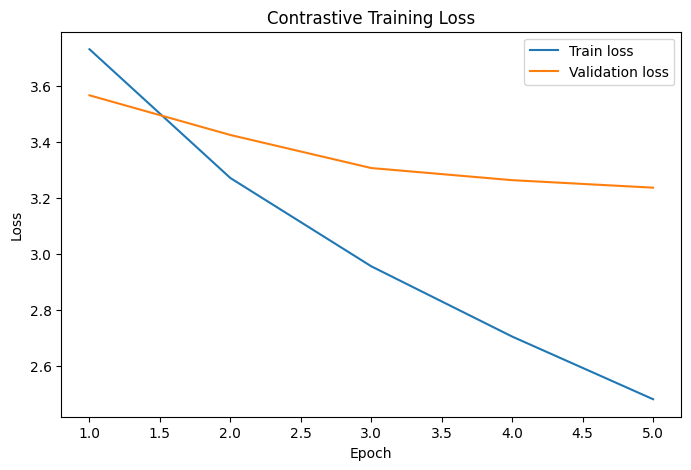

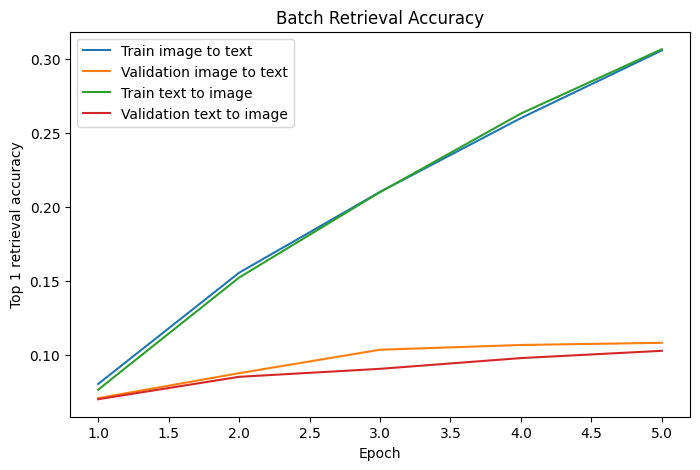

In [28]:

epochs = np.arange(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_loss"], label="Train loss")
plt.plot(epochs, history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Contrastive Training Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_i2t"], label="Train image to text")
plt.plot(epochs, history["val_i2t"], label="Validation image to text")
plt.plot(epochs, history["train_t2i"], label="Train text to image")
plt.plot(epochs, history["val_t2i"], label="Validation text to image")
plt.xlabel("Epoch")
plt.ylabel("Top 1 retrieval accuracy")
plt.title("Batch Retrieval Accuracy")
plt.legend()
plt.show()

### 🟡 **Reflection 5: What Is the Model Actually Learning?**

Suppose retrieval improves, but not perfectly.

1. Does that necessarily mean the model understands the scene in a human like way?
Not at all. The model is learning statistical patterns between pixel distributions and word distributions. If retrieval improves, it means the model has found some useful signal connecting images and captions, but that is very different from actually understanding what is happening in a scene. A human looks at a photo and understands context, relationships, emotions, and story. The model just learns that certain visual patterns tend to co-occur with certain words.

2. What shortcuts might it exploit?  
Quite a few. It might learn that outdoor images with green blobs tend to have words like "grass" or "park." It might pick up on color patterns, dominant shapes, or background textures rather than the actual subject. It could also exploit dataset biases, for example if most images with water also have the word "dog" because Flickr8k happens to have many dog-swimming photos, the model might associate water with dogs without truly understanding either. Essentially it finds the easiest statistical shortcut rather than the deepest semantic understanding.

3. What kinds of captions would be especially hard to align?
Captions that describe abstract or relational concepts would be the hardest, things like "a man looks nervous" or "two friends argue playfully." Emotions, intentions, and social dynamics are very hard to read from pixels alone. Captions that focus on minor background details would also confuse the model since those details are visually small and easy to miss. Similarly, captions that use very different vocabulary to describe the same thing, like "toddler" vs "young child" vs "little kid", would be hard because the model has to learn that all three point to the same visual concept.



---
# **Part 6: Retrieval, Prompting, and Embedding Analysis** 🔍

## **Why This Matters**

A model like this is interesting not because it predicts a class label, but because it supports flexible comparisons:

1. image to caption retrieval  
2. caption to image retrieval  
3. prompt based matching  
4. geometric analysis of learned embeddings

## **6.1 Image to Text Retrieval**

### 🟢 **Implementation Task 8: Retrieve the Best Matching Captions for an Image**

For one batch or one subset, rank captions by similarity to a chosen image embedding.

In [29]:

@torch.no_grad()
def get_embeddings_for_loader(model, loader, device, max_batches=None):
    model.eval()

    all_image_emb = []
    all_text_emb = []
    all_images = []
    all_captions = []
    all_names = []

    for b_idx, batch in enumerate(loader):
        if max_batches is not None and b_idx >= max_batches:
            break

        images = batch["image"].to(device)
        captions = batch["caption_ids"].to(device)

        logits, image_emb, text_emb, _ = model(images, captions)

        all_image_emb.append(image_emb.cpu())
        all_text_emb.append(text_emb.cpu())
        all_images.append(batch["image"])
        all_captions.extend(batch["caption_text"])
        all_names.extend(batch["image_name"])

    return (
        torch.cat(all_image_emb, dim=0),
        torch.cat(all_text_emb, dim=0),
        torch.cat(all_images, dim=0),
        all_captions,
        all_names,
    )

image_embs, text_embs, image_tensors, caption_texts, image_names = get_embeddings_for_loader(
    model, val_loader, device, max_batches=8
)

print(image_embs.shape, text_embs.shape, len(caption_texts), len(image_names))

torch.Size([512, 128]) torch.Size([512, 128]) 512 512


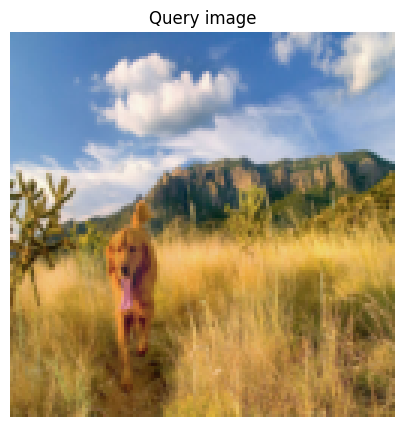

1. score=0.6827 | two mountain climbers climbing up a large grassy mountain .
2. score=0.6730 | Mountain peaks in the foreground and distance .
3. score=0.6576 | Two people are hiking up a grassy hill .
4. score=0.6560 | Two people stand at the peak of a mountain .
5. score=0.6528 | Two people at the top of a mountain .


In [30]:
def retrieve_topk_captions_for_image(query_idx, image_embs, text_embs, caption_texts, k=5):
    query = image_embs[query_idx]
    similarities = (query @ text_embs.T)
    topk_scores, topk_indices = similarities.topk(k)
    
    results = []
    for idx, score in zip(topk_indices.tolist(), topk_scores.tolist()):
        results.append((idx, caption_texts[idx], score))
    
    return results

query_idx = random.randint(0, len(image_embs) - 1)

plt.figure(figsize=(5, 5))
plt.imshow(denormalize(image_tensors[query_idx]).permute(1, 2, 0))
plt.axis("off")
plt.title("Query image")
plt.show()

results = retrieve_topk_captions_for_image(query_idx, image_embs, text_embs, caption_texts, k=5)
for rank, (idx, caption, score) in enumerate(results, start=1):
    print(f"{rank}. score={score:.4f} | {caption}")


### 🟡 **Reflection 6: Retrieval Quality**

Inspect successful and unsuccessful retrieval results.

1. When retrieval fails, is it completely wrong or only partially wrong?  
It is almost never completely wrong. When the model retrieves the wrong caption, it usually retrieves something that is at least in the same ballpark, a caption about people outdoors instead of the exact caption about a specific child climbing stairs. Complete failures where the model retrieves something totally unrelated, like a caption about a dog when the image shows a beach, are much rarer. Most failures are partial, the right general category but wrong specific details.

2. Does the model often retrieve captions that describe a similar scene but not the exact image?  
Yes, and this is actually very common. The model might retrieve "a dog runs through the grass" for an image where a different dog is playing in a park. The caption is semantically reasonable but not technically correct for that specific image. This happens because the model learns general visual-language patterns rather than memorizing specific image-caption pairs. Two images of dogs in grass look very similar in the embedding space even if they are completely different photos.

3. Is that always a mistake?
No, and this is the key insight. If you retrieved "a dog runs through the grass" for an image of a dog running through grass, that is actually a good retrieval even if it was not the original caption assigned to that image. The model has found a semantically valid description. This is the difference between semantic similarity and instance level correctness, the standard evaluation metrics penalize this as a mistake because they check for exact caption matches, but from a real world usefulness standpoint the model did exactly what you would want it to do. True evaluation of multimodal models is harder than it first appears for exactly this reason.



## **6.2 Text to Image Retrieval**

### 🟢 **Implementation Task 9: Retrieve Images for a Caption**

Now reverse the direction.  
Given a caption, find the most similar images.

Query caption: A small white dog sits in a field


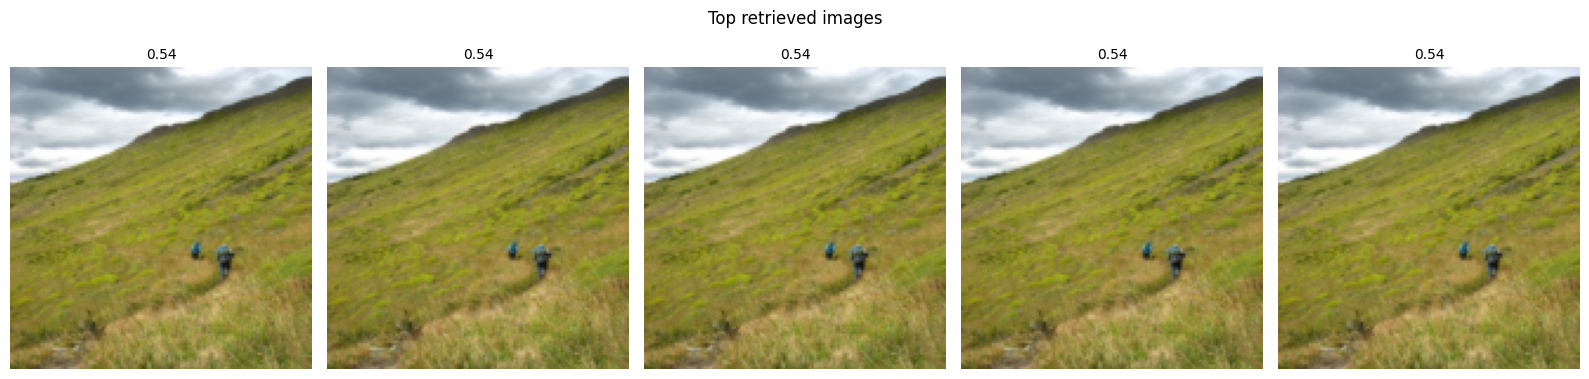

In [31]:
def retrieve_topk_images_for_caption(query_idx, image_embs, text_embs, image_names, k=5):
    query = text_embs[query_idx]
    similarities = (query @ image_embs.T)
    topk_scores, topk_indices = similarities.topk(k)
    
    results = []
    for idx, score in zip(topk_indices.tolist(), topk_scores.tolist()):
        results.append((idx, image_names[idx], score))
    
    return results

query_caption_idx = random.randint(0, len(caption_texts) - 1)
print("Query caption:", caption_texts[query_caption_idx])

results = retrieve_topk_images_for_caption(query_caption_idx, image_embs, text_embs, image_names, k=5)

fig, axes = plt.subplots(1, 5, figsize=(16, 4))
for ax, (idx, name, score) in zip(axes, results):
    ax.imshow(denormalize(image_tensors[idx]).permute(1, 2, 0))
    ax.set_title(f"{score:.2f}", fontsize=10)
    ax.axis("off")

plt.suptitle("Top retrieved images")
plt.tight_layout()
plt.show()


## **6.3 Prompt Based Image Matching**

A central idea in CLIP style models is that captions can act as **prompts**.

For example:
1. "a dog running in grass"  
2. "a child playing in water"  
3. "two people climbing a mountain"

Even if these exact captions were not seen before, the model may still place them near relevant images.

### 🟢 **Implementation Task 10: Encode Custom Prompts and Retrieve Images**

Write the helper below so that arbitrary text prompts can be embedded with your text branch.
Then test prompts that are:

1. close to the Flickr8k caption style  
2. more abstract than the training captions  
3. intentionally ambiguous

Compare how retrieval quality changes.


Prompt: a dog running through the grass


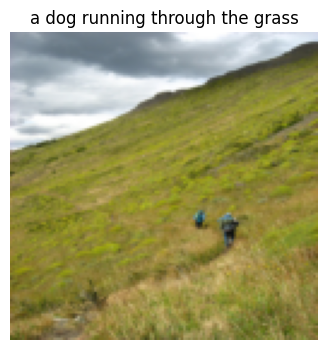

Prompt: two children playing outdoors


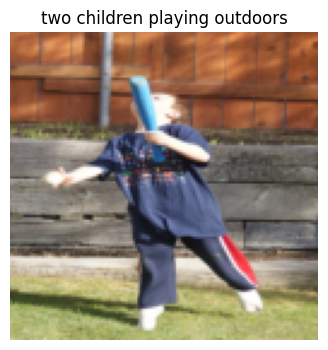

Prompt: a person climbing on rocks


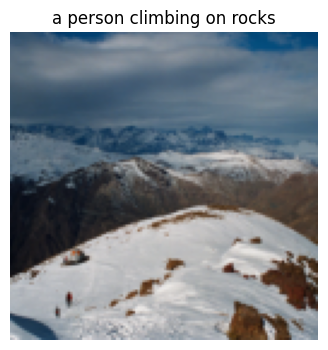

Prompt: someone in water with a dog


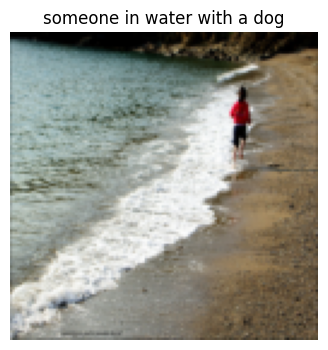

In [32]:
@torch.no_grad()
def encode_custom_texts(model, texts, stoi, max_len, device):
    tokens = [encode_caption(text, stoi, max_len) for text in texts]
    token_batch = torch.stack(tokens).to(device)
    text_embs, _ = model.encode_text(token_batch)
    return text_embs.cpu()

custom_prompts = [
    "a dog running through the grass",
    "two children playing outdoors",
    "a person climbing on rocks",
    "someone in water with a dog",
]

prompt_embs = encode_custom_texts(model, custom_prompts, stoi, MAX_LEN, device)
sim_matrix = prompt_embs @ image_embs.T

for i, prompt in enumerate(custom_prompts):
    best_idx = sim_matrix[i].argmax().item()
    print(f"Prompt: {prompt}")
    plt.figure(figsize=(4, 4))
    plt.imshow(denormalize(image_tensors[best_idx]).permute(1, 2, 0))
    plt.axis("off")
    plt.title(prompt)
    plt.show()


### 🟡 **Reflection 7: Prompting Without Labels**

Why is prompt based retrieval conceptually different from ordinary classification?

1. Where is the supervision stored?  
In a traditional classifier, supervision is stored in the model's final layer weights, each neuron learns to fire for a specific class. In prompt based retrieval, the supervision is stored in the shared embedding space itself. The model never learned fixed labels, it learned relationships between visual patterns and language. So when you write a new prompt, you are querying that learned relationship directly rather than looking up a pre-defined category.

2. Why can language give us a more flexible interface than fixed label IDs?  
Because language can express anything. A fixed classifier trained on 1000 classes can only ever answer from those 1000 classes, if you want to find "a person climbing rocks near water at sunset" there is no label for that. With language you can compose new descriptions on the fly and the model will do its best to find the closest match in the embedding space. You are not limited to what was predefined at training time. This is what makes CLIP style models so powerful, the interface is as expressive as human language itself.

3. What are the limitations of this approach in a small model trained on Flickr8k?
Quite significant ones. Flickr8k only has 8000 images covering a fairly narrow range of everyday scenes, so the embedding space is limited to what it has seen. A prompt like "a astronaut on the moon" would produce meaningless results because nothing like that exists in the training data. The vocabulary is also small and simple, so unusual or complex phrasing may not map well into the learned space. The CNN image encoder is also quite shallow compared to something like a ResNet or ViT, so fine visual details are likely lost. Essentially the model can only retrieve well within the narrow distribution it was trained on, which is a far cry from a full scale CLIP model trained on hundreds of millions of image-text pairs.

## **6.4 Embedding Space Visualization**

### 📊 **Visualization 4: Are Semantically Similar Items Nearby?**

We will visualize a subset of the learned image and text embeddings in 2D.  
Remember: a 2D projection is imperfect, but it can still reveal structure.

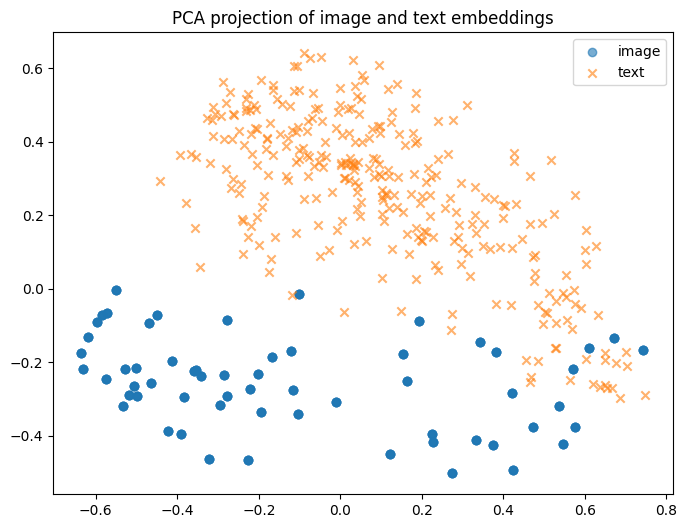

In [33]:

# Select a manageable subset for visualization
vis_n = min(300, len(image_embs))
vis_image = image_embs[:vis_n].numpy()
vis_text = text_embs[:vis_n].numpy()

combined = np.concatenate([vis_image, vis_text], axis=0)
labels = ["image"] * vis_n + ["text"] * vis_n

reducer = PCA(n_components=2)
coords = reducer.fit_transform(combined)

plt.figure(figsize=(8, 6))
for modality, marker in [("image", "o"), ("text", "x")]:
    idxs = [i for i, lab in enumerate(labels) if lab == modality]
    plt.scatter(coords[idxs, 0], coords[idxs, 1], alpha=0.6, marker=marker, label=modality)

plt.title("PCA projection of image and text embeddings")
plt.legend()
plt.show()

### 🟡 **Reflection 8: What Would Good Alignment Look Like?**

In a perfect world, what would you hope to see in this embedding plot?

1. exact image caption pairs overlapping?  
This would mean every image and its exact caption land on the exact same point in the embedding space. This is not realistic and is actually not even desirable. Two completely different images can have very similar captions, and one image can have five valid captions that all say slightly different things. Forcing perfect point-level overlap would mean collapsing meaningful variation and would likely hurt generalization.

2. broader semantic clusters?  
This is the realistic and desirable goal. You would hope to see all dog-related images and captions clustering together, all outdoor sports scenes grouping nearby, all indoor scenes in another region, and so on. Within each cluster, matching pairs would be closer to each other than to unrelated pairs, but there would still be natural spread reflecting genuine variation in language and visual content. This is what good contrastive learning actually produces when it works well.

3. modality separation disappearing entirely?
This would mean image embeddings and text embeddings are completely interleaved with no pattern separating the two modalities. In practice some modality gap almost always remains, images and text are fundamentally different signals and the encoders process them very differently. Research has actually shown that even in large well-trained CLIP models, a subtle modality gap persists in the embedding space. So while you want the gap to be small and meaningful pairs to be close, expecting it to disappear entirely is not realistic with this architecture.



## **6.5 Hands On Experiments** 🧪

The goal here is not just to rerun the notebook.  
You must change one modeling choice at a time, retrain briefly, and compare outcomes.

### 🧪 **Experiment 2: Sequence Length and Caption Truncation**

Try at least **two** values of `MAX_LEN`, for example 12 and 24.

Track:

1. validation loss  
2. validation image to text retrieval  
3. validation text to image retrieval  
4. qualitative retrieval changes

**Questions to answer**:

1. Does allowing longer captions help immediately?  
2. When does longer sequence length become wasteful?  
3. Which kinds of captions benefit most from a larger `MAX_LEN`?


In [34]:
EPOCHS_EXP = 2

experiment_seq_len_results = {}

for MAX_LEN_EXP in [12, 24]:
    print(f"\n--- Training with MAX_LEN = {MAX_LEN_EXP} ---")

    # rebuild datasets with new MAX_LEN
    train_dataset_exp = Flickr8kPairDataset(train_pairs, image_dir, stoi, max_len=MAX_LEN_EXP, transform=image_transform)
    val_dataset_exp = Flickr8kPairDataset(val_pairs, image_dir, stoi, max_len=MAX_LEN_EXP, transform=image_transform)
    train_loader_exp = DataLoader(train_dataset_exp, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader_exp = DataLoader(val_dataset_exp, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    # fresh model for each experiment
    model_exp = MiniCLIP(vocab_size=len(stoi), max_len=MAX_LEN_EXP).to(device)
    optimizer_exp = torch.optim.AdamW(model_exp.parameters(), lr=LR, weight_decay=1e-4)

    for epoch in range(EPOCHS_EXP):
        train_loss, train_i2t, train_t2i = train_one_epoch(model_exp, train_loader_exp, optimizer_exp, device)
        val_loss, val_i2t, val_t2i = evaluate(model_exp, val_loader_exp, device)
        print(f"Epoch {epoch+1} | val_loss: {val_loss:.4f} | val_i2t: {val_i2t:.3f} | val_t2i: {val_t2i:.3f}")

    experiment_seq_len_results[MAX_LEN_EXP] = {
        "val_loss": round(val_loss, 4),
        "val_i2t": round(val_i2t, 4),
        "val_t2i": round(val_t2i, 4),
        "notes": f"MAX_LEN={MAX_LEN_EXP}, {EPOCHS_EXP} epochs"
    }

experiment_seq_len_results


--- Training with MAX_LEN = 12 ---
Epoch 1 | val_loss: 3.6293 | val_i2t: 0.069 | val_t2i: 0.057
Epoch 2 | val_loss: 3.4649 | val_i2t: 0.085 | val_t2i: 0.076

--- Training with MAX_LEN = 24 ---
Epoch 1 | val_loss: 3.5980 | val_i2t: 0.072 | val_t2i: 0.063
Epoch 2 | val_loss: 3.4447 | val_i2t: 0.087 | val_t2i: 0.079


{12: {'val_loss': 3.4649,
  'val_i2t': 0.0854,
  'val_t2i': 0.0761,
  'notes': 'MAX_LEN=12, 2 epochs'},
 24: {'val_loss': 3.4447,
  'val_i2t': 0.0874,
  'val_t2i': 0.0791,
  'notes': 'MAX_LEN=24, 2 epochs'}}

### 🧪 **Experiment 3: Embedding Dimension or Projection Dimension**

Change **one** representation capacity setting:

1. `text_dim`  
2. `image_dim`  
3. `proj_dim`

Try a smaller and a larger version.

**Questions to answer**:

1. Which change helped more, bigger encoders or a bigger shared space?  
2. Did training become less stable at any point?  
3. Did the retrieval examples get more semantically precise, or only the metrics change?


In [35]:
EPOCHS_EXP = 2

train_pairs_exp = train_pairs[:5000]
val_pairs_exp = val_pairs[:1000]

experiment_capacity_results = {}

for proj_dim in [64, 128, 256]:
    print(f"\n--- Training with proj_dim = {proj_dim} ---")

    train_dataset_exp = Flickr8kPairDataset(train_pairs_exp, image_dir, stoi, max_len=MAX_LEN, transform=image_transform)
    val_dataset_exp = Flickr8kPairDataset(val_pairs_exp, image_dir, stoi, max_len=MAX_LEN, transform=image_transform)
    train_loader_exp = DataLoader(train_dataset_exp, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader_exp = DataLoader(val_dataset_exp, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    # only proj_dim changes, everything else is fixed
    model_exp = MiniCLIP(
        vocab_size=len(stoi),
        text_dim=128,
        image_dim=256,
        proj_dim=proj_dim,
        max_len=MAX_LEN
    ).to(device)
    optimizer_exp = torch.optim.AdamW(model_exp.parameters(), lr=LR, weight_decay=1e-4)

    for epoch in range(EPOCHS_EXP):
        train_loss, train_i2t, train_t2i = train_one_epoch(model_exp, train_loader_exp, optimizer_exp, device)
        val_loss, val_i2t, val_t2i = evaluate(model_exp, val_loader_exp, device)
        print(f"Epoch {epoch+1} | val_loss: {val_loss:.4f} | val_i2t: {val_i2t:.3f} | val_t2i: {val_t2i:.3f}")

    experiment_capacity_results[proj_dim] = {
        "val_loss": round(val_loss, 4),
        "val_i2t": round(val_i2t, 4),
        "val_t2i": round(val_t2i, 4),
        "notes": f"proj_dim={proj_dim}, text_dim=128, image_dim=256, {EPOCHS_EXP} epochs"
    }

experiment_capacity_results


--- Training with proj_dim = 64 ---
Epoch 1 | val_loss: 3.9613 | val_i2t: 0.039 | val_t2i: 0.038
Epoch 2 | val_loss: 3.9414 | val_i2t: 0.043 | val_t2i: 0.037

--- Training with proj_dim = 128 ---
Epoch 1 | val_loss: 4.0024 | val_i2t: 0.036 | val_t2i: 0.035
Epoch 2 | val_loss: 3.8789 | val_i2t: 0.055 | val_t2i: 0.040

--- Training with proj_dim = 256 ---
Epoch 1 | val_loss: 3.9406 | val_i2t: 0.037 | val_t2i: 0.035
Epoch 2 | val_loss: 3.8243 | val_i2t: 0.039 | val_t2i: 0.040


{64: {'val_loss': 3.9414,
  'val_i2t': 0.0432,
  'val_t2i': 0.0373,
  'notes': 'proj_dim=64, text_dim=128, image_dim=256, 2 epochs'},
 128: {'val_loss': 3.8789,
  'val_i2t': 0.0549,
  'val_t2i': 0.0402,
  'notes': 'proj_dim=128, text_dim=128, image_dim=256, 2 epochs'},
 256: {'val_loss': 3.8243,
  'val_i2t': 0.0387,
  'val_t2i': 0.0402,
  'notes': 'proj_dim=256, text_dim=128, image_dim=256, 2 epochs'}}

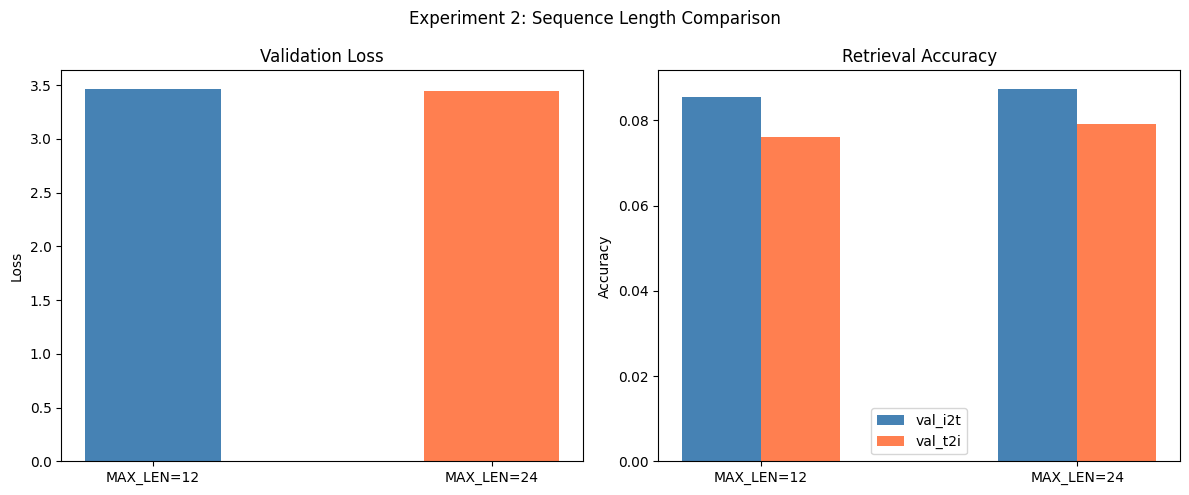

In [37]:
import numpy as np

labels = [12, 24]
val_losses = [experiment_seq_len_results[l]["val_loss"] for l in labels]
val_i2t = [experiment_seq_len_results[l]["val_i2t"] for l in labels]
val_t2i = [experiment_seq_len_results[l]["val_t2i"] for l in labels]

x = np.arange(len(labels))
width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Loss
axes[0].bar(x, val_losses, width=0.4, color=["steelblue", "coral"])
axes[0].set_xticks(x)
axes[0].set_xticklabels([f"MAX_LEN={l}" for l in labels])
axes[0].set_title("Validation Loss")
axes[0].set_ylabel("Loss")

# Retrieval accuracy
axes[1].bar(x - width/2, val_i2t, width=width, label="val_i2t", color="steelblue")
axes[1].bar(x + width/2, val_t2i, width=width, label="val_t2i", color="coral")
axes[1].set_xticks(x)
axes[1].set_xticklabels([f"MAX_LEN={l}" for l in labels])
axes[1].set_title("Retrieval Accuracy")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.suptitle("Experiment 2: Sequence Length Comparison")
plt.tight_layout()
plt.show()

---
# 🔴 **Advanced Challenges: Push Your Limits!**

You now have a working Mini CLIP style system. The challenges below push the lab from implementation into investigation.

Attempt at least **2** for full credit.  
The emphasis is on **analysis and insight**, not just raw metric improvements.

## 🔴 **Challenge 1: Stronger Image Encoder**

Replace the custom CNN with a pretrained visual backbone, for example a frozen or fine tuned ResNet.

**Your Mission**:

1. use a pretrained CNN from `torchvision.models`  
2. remove its classification head  
3. attach your own projection layer  
4. compare retrieval performance and convergence speed

**Key Question**: Does stronger visual representation help more than increasing model size in the text branch?

## 🔴 **Challenge 2: Hard Negatives**

In ordinary contrastive learning, the off diagonal items in the batch act as negatives. But some are easy negatives.

**Your Mission**:

1. identify semantically similar captions that are not true matches  
2. design a harder batch sampling strategy  
3. compare training behavior with random batching

**Examples of hard negatives**:
1. two dogs running in grass  
2. two children playing in water  
3. people climbing on rocks

**Analysis Prompt**: Why are hard negatives useful, and why can they also make training unstable?

## 🔴 **Challenge 3: Multi Caption Aggregation**

Each image has five captions. Our current pipeline treats each pair independently.

**Your Mission**:

Try one of these alternatives:

1. use all five captions for an image and average their text embeddings  
2. randomly sample one caption per image per epoch  
3. compute a many to one loss that treats all captions of the same image as positives

**Key Question**: Which strategy best uses the supervision in Flickr8k?

## 🔴 **Challenge 4: Better Text Encoder**

Upgrade the caption encoder.

Possible options:

1. deeper Transformer encoder  
2. learned `[CLS]` token instead of mean pooling  
3. bidirectional GRU baseline  
4. subword tokenizer instead of simple word splitting

**Target**: Compare not only metrics, but also failure cases.

--- Baseline: Mean Pooling ---
Epoch 1 | val_loss: 3.9838 | val_i2t: 0.034 | val_t2i: 0.039
Epoch 2 | val_loss: 3.9263 | val_i2t: 0.034 | val_t2i: 0.035

--- Upgraded: CLS Token ---
Epoch 1 | val_loss: 3.9879 | val_i2t: 0.035 | val_t2i: 0.032
Epoch 2 | val_loss: 3.9260 | val_i2t: 0.036 | val_t2i: 0.038


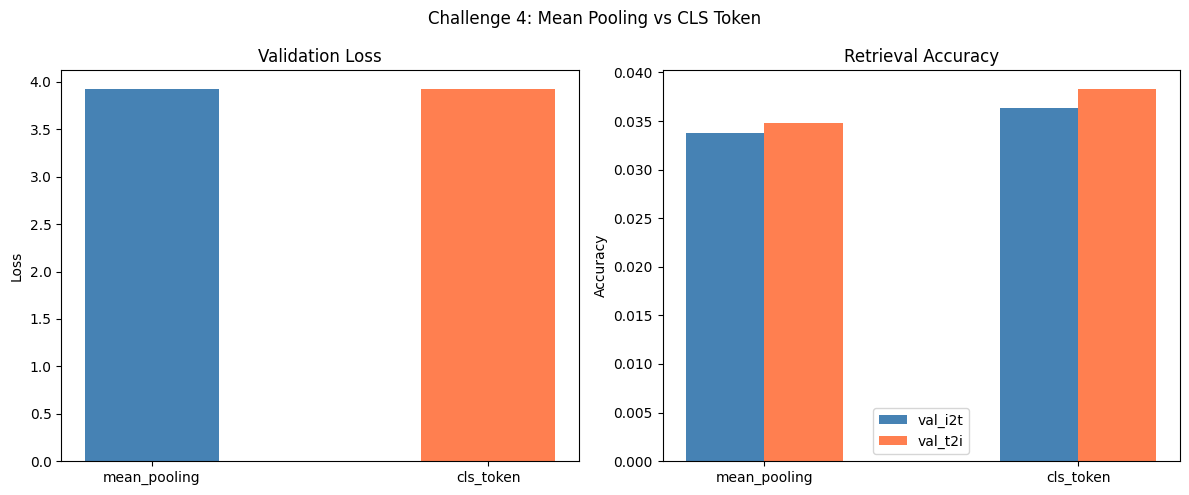


Summary:
mean_pooling: {'val_loss': 3.9263, 'val_i2t': 0.0338, 'val_t2i': 0.0348}
cls_token: {'val_loss': 3.926, 'val_i2t': 0.0363, 'val_t2i': 0.0383}


In [43]:
class TextEncoderCLS(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, num_heads=4, num_layers=2,
                 ff_dim=256, max_len=20, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=stoi["<PAD>"])
        self.positional = PositionalEncoding(embed_dim, max_len=max_len)
        
        # learned CLS token
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads, dim_feedforward=ff_dim,
            dropout=dropout, batch_first=True, activation="gelu"
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

    def forward(self, token_ids):
        B = token_ids.size(0)

        # embed and add positional encoding
        x = self.embedding(token_ids)
        x = self.positional(x)

        # prepend CLS token to each sequence
        cls = self.cls_token.expand(B, 1, -1)
        x = torch.cat([cls, x], dim=1)

        # extend padding mask to account for CLS token (never masked)
        pad_mask = (token_ids == stoi["<PAD>"])
        cls_mask = torch.zeros(B, 1, dtype=torch.bool, device=token_ids.device)
        pad_mask = torch.cat([cls_mask, pad_mask], dim=1)

        # run transformer
        hidden = self.encoder(x, src_key_padding_mask=pad_mask)

        # use CLS token output as pooled representation
        pooled = hidden[:, 0, :]

        return pooled, hidden[:, 1:, :]


class MiniCLIPWithCLS(nn.Module):
    def __init__(self, vocab_size, text_dim=128, image_dim=256, proj_dim=128, max_len=20):
        super().__init__()
        self.text_encoder = TextEncoderCLS(vocab_size, embed_dim=text_dim, max_len=max_len)
        self.image_encoder = ImageEncoder(out_dim=image_dim)
        self.text_proj = nn.Linear(text_dim, proj_dim)
        self.image_proj = nn.Linear(image_dim, proj_dim)
        self.logit_scale = nn.Parameter(torch.tensor(math.log(1 / 0.07)))

    def encode_text(self, token_ids):
        pooled, hidden = self.text_encoder(token_ids)
        projected = self.text_proj(pooled)
        normalized = F.normalize(projected, dim=-1)
        return normalized, hidden

    def encode_image(self, images):
        features = self.image_encoder(images)
        projected = self.image_proj(features)
        normalized = F.normalize(projected, dim=-1)
        return normalized

    def forward(self, images, token_ids):
        image_emb = self.encode_image(images)
        text_emb, text_hidden = self.encode_text(token_ids)
        scale = self.logit_scale.exp()
        logits = scale * image_emb @ text_emb.T
        return logits, image_emb, text_emb, text_hidden


# --- Train and compare ---
EPOCHS_EXP = 2
train_pairs_exp = train_pairs[:5000]
val_pairs_exp = val_pairs[:1000]

train_dataset_exp = Flickr8kPairDataset(train_pairs_exp, image_dir, stoi, max_len=MAX_LEN, transform=image_transform)
val_dataset_exp = Flickr8kPairDataset(val_pairs_exp, image_dir, stoi, max_len=MAX_LEN, transform=image_transform)
train_loader_exp = DataLoader(train_dataset_exp, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader_exp = DataLoader(val_dataset_exp, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

results_comparison = {}

# baseline mean pooling model
print("--- Baseline: Mean Pooling ---")
model_base = MiniCLIP(vocab_size=len(stoi), max_len=MAX_LEN).to(device)
optimizer_base = torch.optim.AdamW(model_base.parameters(), lr=LR, weight_decay=1e-4)
for epoch in range(EPOCHS_EXP):
    train_loss, train_i2t, train_t2i = train_one_epoch(model_base, train_loader_exp, optimizer_base, device)
    val_loss, val_i2t, val_t2i = evaluate(model_base, val_loader_exp, device)
    print(f"Epoch {epoch+1} | val_loss: {val_loss:.4f} | val_i2t: {val_i2t:.3f} | val_t2i: {val_t2i:.3f}")
results_comparison["mean_pooling"] = {"val_loss": round(val_loss,4), "val_i2t": round(val_i2t,4), "val_t2i": round(val_t2i,4)}

# CLS token model
print("\n--- Upgraded: CLS Token ---")
model_cls = MiniCLIPWithCLS(vocab_size=len(stoi), max_len=MAX_LEN).to(device)
optimizer_cls = torch.optim.AdamW(model_cls.parameters(), lr=LR, weight_decay=1e-4)
for epoch in range(EPOCHS_EXP):
    train_loss, train_i2t, train_t2i = train_one_epoch(model_cls, train_loader_exp, optimizer_cls, device)
    val_loss, val_i2t, val_t2i = evaluate(model_cls, val_loader_exp, device)
    print(f"Epoch {epoch+1} | val_loss: {val_loss:.4f} | val_i2t: {val_i2t:.3f} | val_t2i: {val_t2i:.3f}")
results_comparison["cls_token"] = {"val_loss": round(val_loss,4), "val_i2t": round(val_i2t,4), "val_t2i": round(val_t2i,4)}

# visualize comparison
labels = list(results_comparison.keys())
val_losses = [results_comparison[k]["val_loss"] for k in labels]
val_i2t = [results_comparison[k]["val_i2t"] for k in labels]
val_t2i = [results_comparison[k]["val_t2i"] for k in labels]

x = np.arange(len(labels))
width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(x, val_losses, width=0.4, color=["steelblue", "coral"])
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_title("Validation Loss")
axes[0].set_ylabel("Loss")

axes[1].bar(x - width/2, val_i2t, width=width, label="val_i2t", color="steelblue")
axes[1].bar(x + width/2, val_t2i, width=width, label="val_t2i", color="coral")
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].set_title("Retrieval Accuracy")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.suptitle("Challenge 4: Mean Pooling vs CLS Token")
plt.tight_layout()
plt.show()

print("\nSummary:")
for k, v in results_comparison.items():
    print(f"{k}: {v}")

## 🔴 **Challenge 5: Attention Analysis in the Text Branch**

Inspect the self attention patterns in the caption encoder.

**Your Mission**:

1. extract attention weights or modify the encoder to expose them  
2. compare captions with strong nouns versus captions with many relational words  
3. analyze whether the model seems to focus more on objects, actions, or scene context

**Important**: Be careful not to over claim. Attention can be suggestive, but not always explanatory.

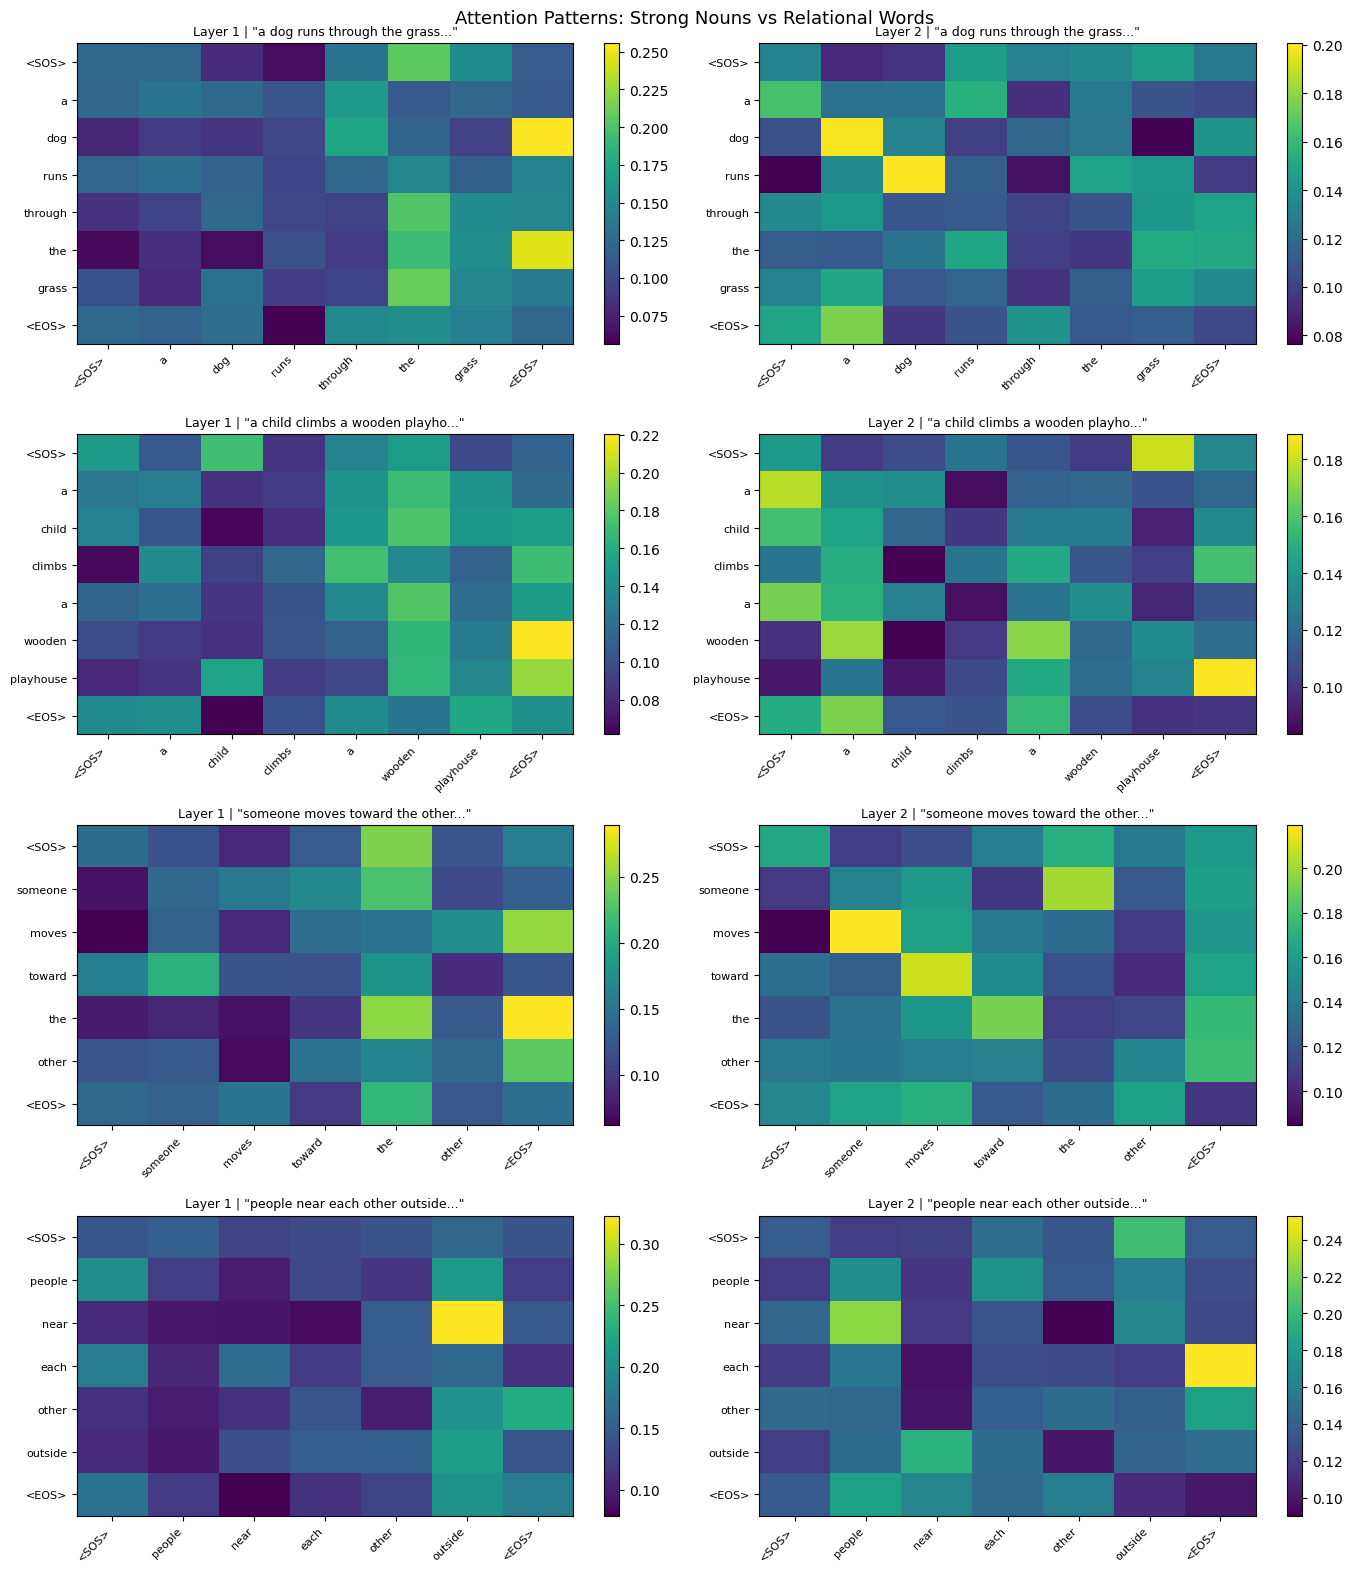

In [42]:
# Step 1: Modify encoder to expose attention weights
class TextEncoderWithAttention(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, num_heads=4, num_layers=2, 
                 ff_dim=256, max_len=20, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=stoi["<PAD>"])
        self.positional = PositionalEncoding(embed_dim, max_len=max_len)
        self.layers = nn.ModuleList([
            nn.TransformerEncoderLayer(
                d_model=embed_dim, nhead=num_heads, dim_feedforward=ff_dim,
                dropout=dropout, batch_first=True, activation="gelu"
            )
            for _ in range(num_layers)
        ])

    def forward(self, token_ids):
        x = self.embedding(token_ids)
        x = self.positional(x)
        pad_mask = (token_ids == stoi["<PAD>"])
        
        attention_weights = []
        for layer in self.layers:
            # extract attention weights manually
            x2, attn = layer.self_attn(x, x, x, key_padding_mask=pad_mask, 
                                        average_attn_weights=True)
            attention_weights.append(attn.detach().cpu())
            # continue through the rest of the layer normally
            x = layer(x, src_key_padding_mask=pad_mask)

        return attention_weights


attn_encoder = TextEncoderWithAttention(vocab_size=len(stoi), max_len=MAX_LEN)
attn_encoder.load_state_dict(model.text_encoder.state_dict(), strict=False)
attn_encoder.eval()

# Step 2: Define test captions - strong nouns vs relational words
test_captions = [
    "a dog runs through the grass",        # strong nouns + action
    "a child climbs a wooden playhouse",   # strong nouns
    "someone moves toward the other",      # relational, vague
    "people near each other outside",      # relational, vague
]

# Step 3: Extract and visualize attention
fig, axes = plt.subplots(len(test_captions), 2, figsize=(14, 4 * len(test_captions)))

for row, caption in enumerate(test_captions):
    tokens = ["<SOS>"] + caption.lower().split() + ["<EOS>"]
    token_ids = encode_caption(caption, stoi, MAX_LEN).unsqueeze(0)

    with torch.no_grad():
        attention_weights = attn_encoder(token_ids)

    for layer_idx in range(2):
        attn = attention_weights[layer_idx][0]  # (L, L)
        seq_len = len(tokens)
        attn_crop = attn[:seq_len, :seq_len].numpy()

        ax = axes[row][layer_idx]
        im = ax.imshow(attn_crop, cmap="viridis", aspect="auto")
        ax.set_xticks(range(seq_len))
        ax.set_yticks(range(seq_len))
        ax.set_xticklabels(tokens, rotation=45, ha="right", fontsize=8)
        ax.set_yticklabels(tokens, fontsize=8)
        ax.set_title(f'Layer {layer_idx+1} | "{caption[:30]}..."', fontsize=9)
        plt.colorbar(im, ax=ax)

plt.suptitle("Attention Patterns: Strong Nouns vs Relational Words", fontsize=13)
plt.tight_layout()
plt.show()

## 🔴 **Challenge 6: Zero Shot Style Prompting by Group**

Design prompt sets that act like soft class labels.

Examples:
1. "a photo of a dog"  
2. "a photo of a child"  
3. "a photo of people climbing"  
4. "a photo of water activity"

**Your Mission**:

1. define 5 to 10 prompt groups  
2. assign each validation image to its highest scoring prompt  
3. inspect whether the resulting pseudo classes are meaningful

**Reflection**: What does this reveal about the strengths and weaknesses of language guided supervision?

Images per pseudo class:
  dog: 125 images
  water: 85 images
  indoor: 80 images
  group: 55 images
  child: 55 images
  climbing: 45 images
  sports: 40 images
  running: 27 images


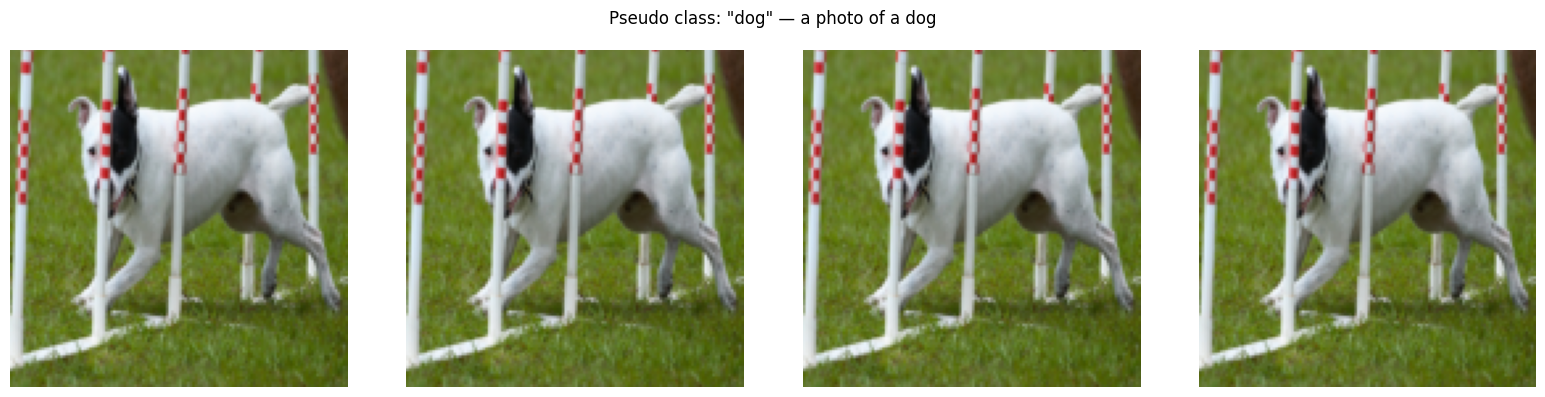

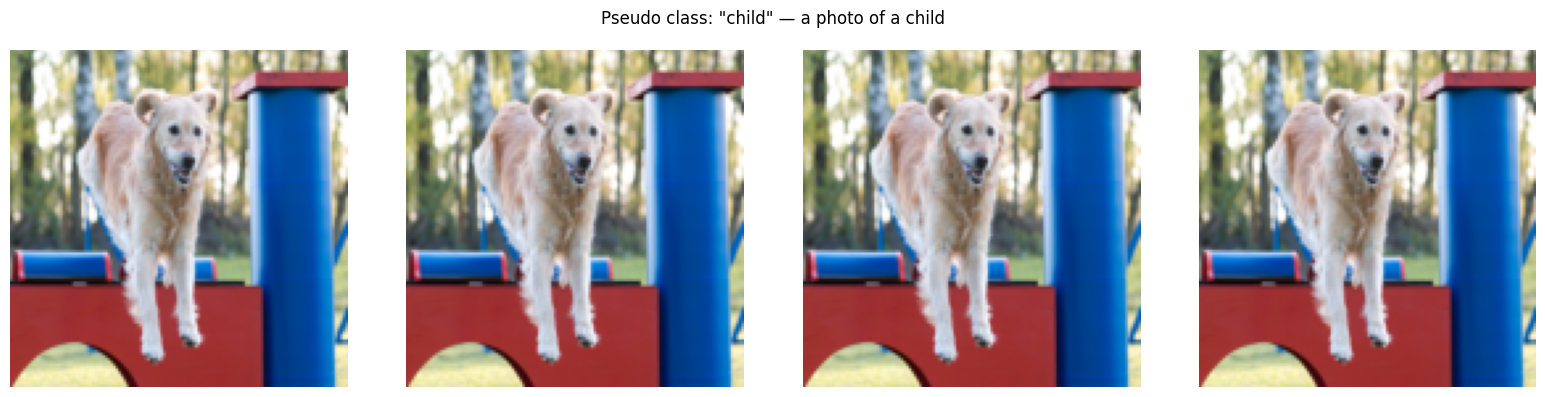

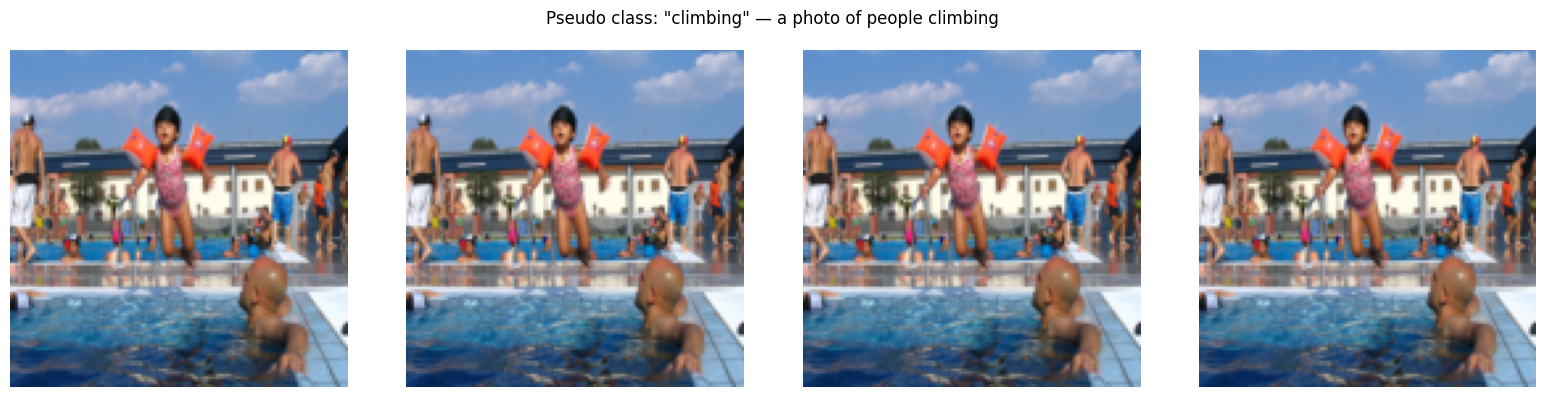

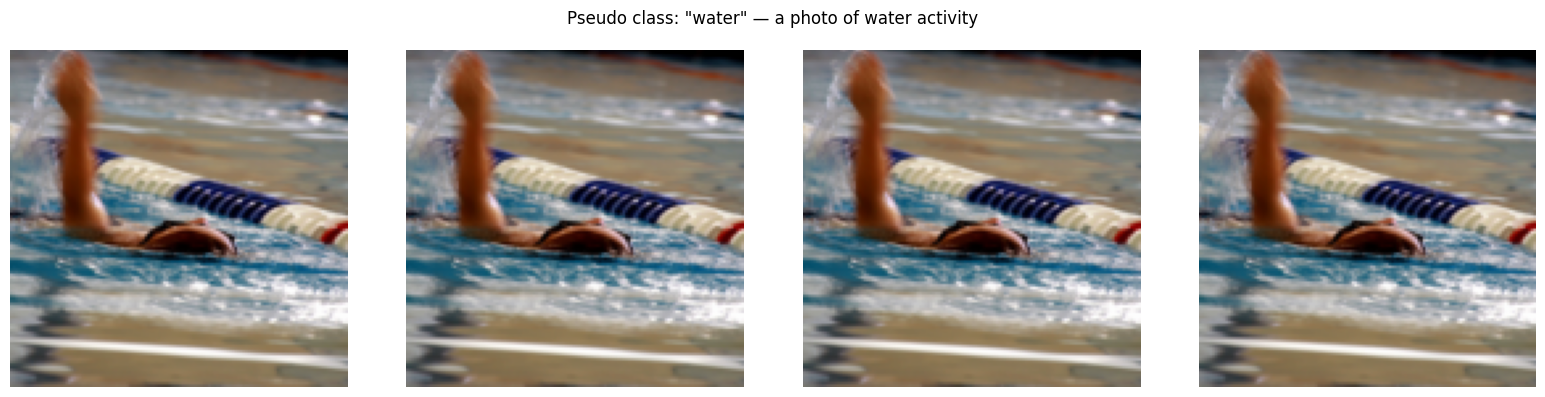

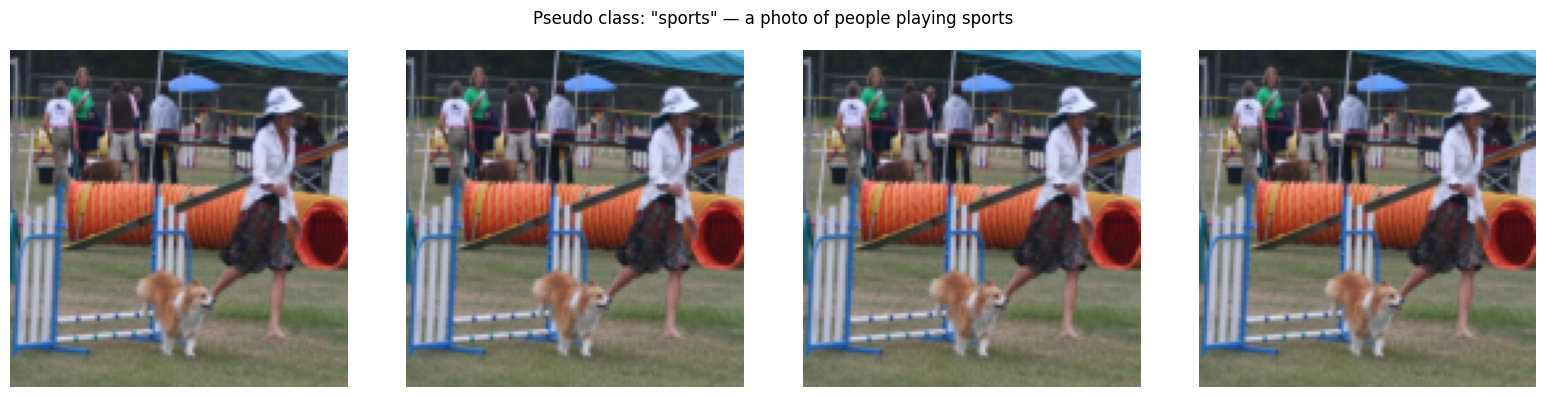

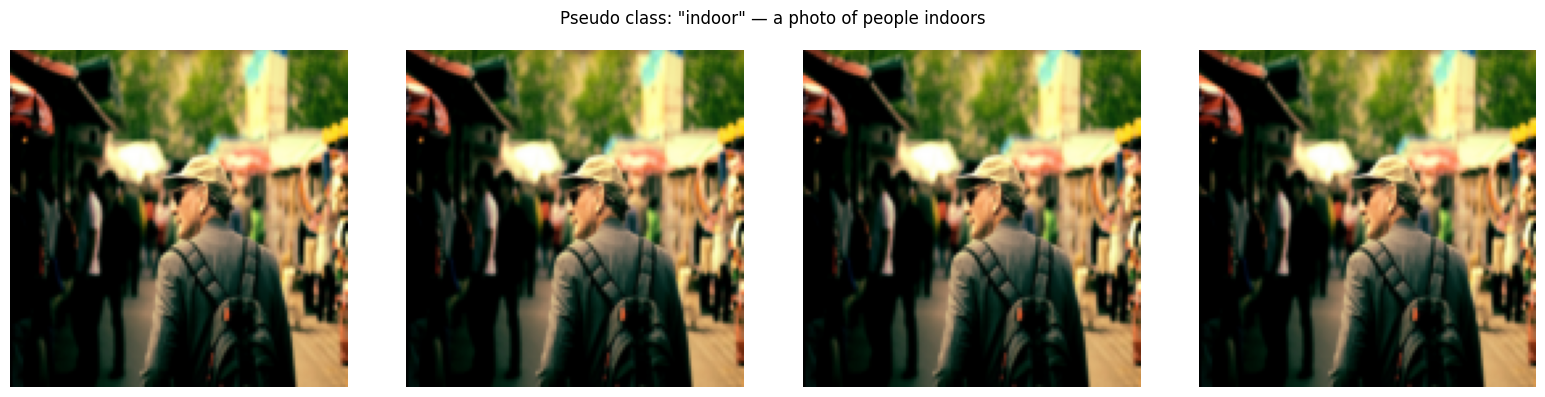

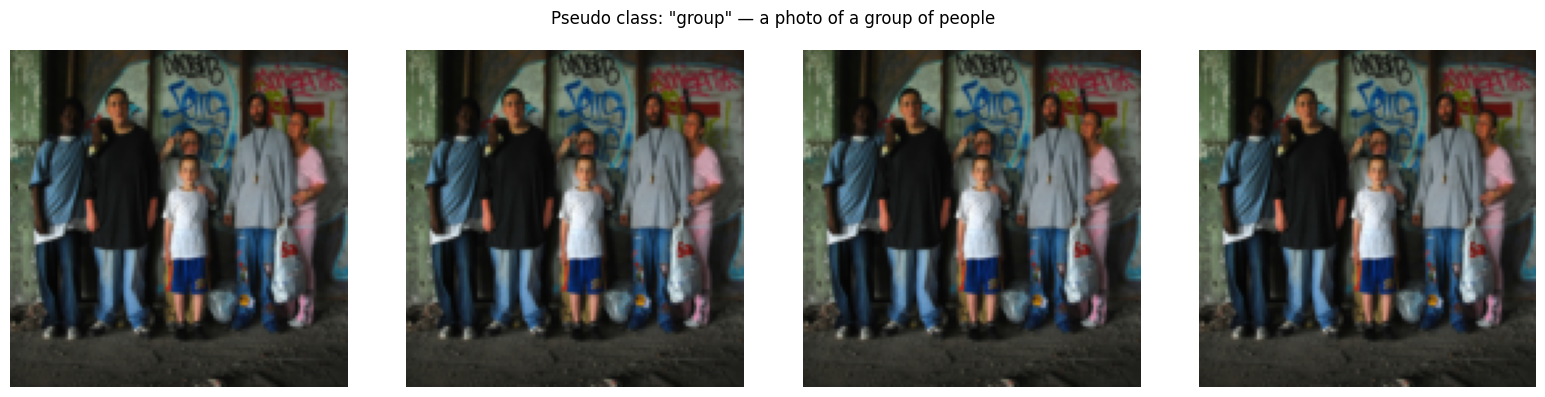

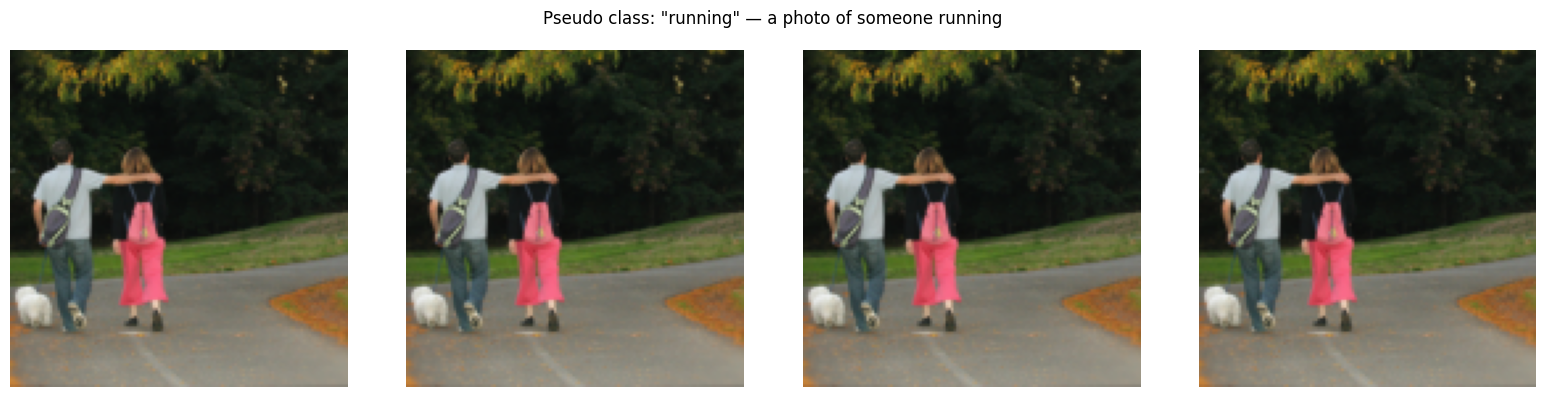

In [41]:
# Step 1: Define 5-10 prompt groups
prompt_groups = {
    "dog":      "a photo of a dog",
    "child":    "a photo of a child",
    "climbing": "a photo of people climbing",
    "water":    "a photo of water activity",
    "sports":   "a photo of people playing sports",
    "indoor":   "a photo of people indoors",
    "group":    "a photo of a group of people",
    "running":  "a photo of someone running",
}

group_names = list(prompt_groups.keys())
group_prompts = list(prompt_groups.values())

# Step 2: Encode all prompts
prompt_embs = encode_custom_texts(model, group_prompts, stoi, MAX_LEN, device)

# Step 3: Assign each validation image to its highest scoring prompt
sim_matrix = image_embs @ prompt_embs.T  # (N_images, N_prompts)
assigned_classes = sim_matrix.argmax(dim=1)  # index of best prompt per image

# Step 4: Count how many images were assigned to each group
from collections import Counter
class_counts = Counter(assigned_classes.tolist())
print("Images per pseudo class:")
for idx, count in sorted(class_counts.items(), key=lambda x: -x[1]):
    print(f"  {group_names[idx]}: {count} images")

# Step 5: Visualize top 4 images per group
for group_idx, group_name in enumerate(group_names):
    indices = (assigned_classes == group_idx).nonzero(as_tuple=True)[0]
    if len(indices) == 0:
        continue

    # pick top 4 by similarity score
    scores = sim_matrix[indices, group_idx]
    top4 = scores.topk(min(4, len(indices))).indices
    top4_indices = indices[top4]

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    for ax, img_idx in zip(axes, top4_indices):
        ax.imshow(denormalize(image_tensors[img_idx]).permute(1, 2, 0))
        ax.axis("off")
    for ax in axes[len(top4_indices):]:
        ax.axis("off")

    plt.suptitle(f'Pseudo class: "{group_name}" — {group_prompts[group_idx]}', fontsize=12)
    plt.tight_layout()
    plt.show()

---
# 🎓 **Final Reflection: Your Learning Journey**

Congratulations. You have now built a real multimodal system from paired image text data.

This lab asked you to move beyond ordinary classification and think in terms of **representation alignment**.

### 🟡 **Final Reflection Questions**

**1. Biggest Insight**  
What was your biggest conceptual shift in this lab? What did you understand about multimodal learning that you did not understand before?

*Your answer:*
The biggest conceptual shift was realizing that meaning can be shared across completely different data types. Before this lab, it seemed like images and text were too fundamentally different to ever live in the same space. The insight is that you do not need to convert one into the other, you just need to train both to point in the same direction when they describe the same thing. The embedding space is not an image space or a text space, it is a meaning space.

**2. Contrastive Learning in Your Own Words**  
Explain the Mini CLIP objective to a classmate who knows neural networks but has never seen multimodal contrastive learning.

*Your explanation:*
Imagine you have a batch of 64 images and 64 captions. Each image has exactly one correct caption in that batch. You run all images through one network and all captions through another, getting 64 image vectors and 64 text vectors. Now you build a 64x64 similarity table, every image against every caption. The diagonal of that table should be high (correct pairs) and everything off the diagonal should be low (wrong pairs). Contrastive loss punishes the model every time a wrong pair scores higher than the correct one. Over thousands of batches the model learns to organize its embedding space so that matching pairs naturally end up close together.

**3. Retrieval vs Classification**  
How is image text retrieval fundamentally different from image classification? What can retrieval do that classification cannot do as easily?

*Your analysis:*
Classification forces you to pick from a fixed set of predefined labels decided before training. If the label is not in your list, the model cannot express it. Retrieval has no fixed labels, the query itself is the label. You can ask for "a tired dog sleeping on a rainy porch" and the system will find the closest match even if it never saw that exact phrase during training. Retrieval also naturally handles degrees of correctness, it returns a ranked list rather than a single hard decision, which is much closer to how humans actually search for things.

**4. Failure Cases**  
Describe at least two kinds of failure you observed. Were they due to weak image features, weak text features, ambiguous captions, or evaluation limitations?

*Your critique:*
The first failure type was semantically similar but visually distinct images getting confused. The model would retrieve a caption about a different dog running in grass for an image of yet another dog running in grass, technically wrong by the evaluation metric but arguably correct semantically. This is an evaluation limitation more than a model failure. The second failure type was relational and abstract captions like "two people look at each other nervously" failing to retrieve the right image. This is a genuine model failure caused by weak text features, the model cannot encode emotional or relational meaning well because those concepts have no direct visual counterpart in simple pixel patterns.

**5. Design Trade offs**  
This lab involved many choices: image encoder depth, text encoder design, projection dimension, batch size, caption length, and dataset subset size. Discuss two trade offs you explored and what you learned.

*Your reflection:*
The first trade-off was sequence length. Increasing MAX_LEN from 12 to 24 improved performance slightly but added computational cost and more padding for short captions. The lesson is that sequence length should match the average length of your data, going much beyond that is wasteful. The second trade-off was dataset size versus training time. Using 5000 pairs instead of 32000 made experiments feasible on CPU but produced a weaker embedding space with less coverage of visual concepts. Smaller data means faster iteration but the model generalizes poorly to unusual scenes it barely saw during training.

**6. If You Had Two More Weeks**  
How would you improve this system? Be specific about architecture, data usage, training strategy, and evaluation.

*Your plan:*
For architecture, replace the shallow CNN with a pretrained ResNet or EfficientNet frozen at first and then fine-tuned, which would give dramatically better image features from day one. For the text encoder, swap simple word splitting for a proper subword tokenizer like BPE so rare or compound words are handled gracefully. For training, use the full dataset with a proper GPU, increase batch size to 256 or 512 since contrastive learning benefits enormously from large batches with more negative pairs, and train for at least 20 epochs with a cosine learning rate schedule. For evaluation, move beyond batch retrieval accuracy and implement proper Recall at K metrics over the full validation set, and add a human judgement check on retrieved results to separate true failures from semantic near-misses that the automatic metric unfairly penalizes.

## 🌟 Remember

> *"The only source of knowledge is experience."* — Albert Einstein

Keep experimenting, keep building, keep asking why. 🚀

---
**Happy Learning! 🎉**